# **Práctica 2: Pre-procesamiento del dataset**
### Introducción a la Ciencia de Datos 
*Alumno: Norman O. Guzmán Chaboya*


Primeramente, importamos las bibliotecas necesarias para este proyecto

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.style.use('bmh')
import seaborn as sns
import textwrap

Definimos la siguiente función para visualizar simultáneamente más de una tabla, obtenida de los aquellas incluídas del [notebook](https://github.com/husseinlopez/PythonDataScienceHandbook/blob/master/notebooks_v1/03.06-Concat-And-Append.ipynb) de Jake VanderPlas:

In [2]:
class display(object):
    # Función para observar simultáneamente múltiples objetos HTML
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p>{1}
    </div>"""
    def __init__(self, *args):
        self.args = args
        
    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                         for a in self.args)
    
    def __repr__(self):
        return '\n\n'.join(a + '\n' + repr(eval(a))
                           for a in self.args)

---

## Conjunto de Datos

El *dataset* seleccionado es [Diabetes 130-US Hospitals for Years 1999-2008](https://archive.ics.uci.edu/dataset/296/diabetes-130-us-hospitals-for-years-1999-2008) y fue donado al repositorio *UCI Machine Learning Repository* el 2 de mayo de 2014. Este conjunto representa diez años (1999-2008) de atención clínica en 130 hospitales y redes integradas de atención en Estados Unidos. Cada registro corresponde a una alta de hospital de un paciente diagnosticado con diabetes, con una estancia de entre 1 y 14 días, durante la cual se realizaron pruebas de laboratorio y se administraron medicamentos. El objetivo original del conjunto es determinar la readmisión temprana del paciente, es decir, aquella que ocurre dentro de los 30 días posteriores al alta.

Este conjunto de datos fue utilizado en el estudio de Strack et al. (2014), [*Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records*](https://doi.org/10.1155/2014/781670), publicado en *BioMed Research International*. Junto con la tabla principal (`diabetic_data.csv`) se distribuye el archivo `IDS_mapping.csv`, un catálogo que describe los códigos numéricos de tres atributos: tipo de ingreso, destino al egreso y procedencia del paciente.

#### Licencia
El conjunto de datos está licenciado bajo la licencia Creative Commons Attribution 4.0 International, la cual permite compartir y adaptar el material para cualquier fin, siempre que se otorgue el crédito correspondiente.


Para cargar la tabla, se utiliza el parámetro `keep_default_na=False` porque, por defecto, `pandas` interpreta la cadena `'None'` como un valor nulo (`NaN`); sin embargo, en los atributos `max_glu_serum` y `A1Cresult` esta cadena es una categoría válida que indica que la prueba *no fue realizada*, por lo que de esta forma conservamos todos los valores tal como fueron reportados (los datos faltantes de la tabla se codifican con el símbolo `'?'`, como se verá más adelante):

In [3]:
data_df = pd.read_csv('./diabetic_data.csv', keep_default_na=False)
data_df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


#### Estructura

A continuación se enlistan los atributos contenidos en la tabla, agrupados de acuerdo a la dimensión a la que pertenecen con respecto al encuentro hospitalario. Esta descripción es un resumen de lo descrito en la documentación del conjunto de datos en el repositorio UCI y en el catálogo adjunto [IDS_mapping.csv](./catalogos/IDS_mapping.csv).

##### Identificación del encuentro y del paciente
- `encounter_id`: Identificador único del encuentro hospitalario (int)
- `patient_nbr`: Identificador único del paciente (int). Un mismo paciente puede tener varios encuentros

##### Perfil del paciente

- `race`: Raza (Caucasian, AfricanAmerican, Asian, Hispanic, Other, `?` = no reportada)
- `gender`: Género (Female, Male, Unknown/Invalid)
- `age`: Grupo de edad, en intervalos de 10 años (desde `[0-10)` hasta `[90-100)`)
- `weight`: Peso en libras, agrupado en intervalos (`?` = no reportado)

In [4]:
df_race = pd.DataFrame({'race': data_df.loc[:, 'race'].value_counts().index,
                        'total': data_df.loc[:, 'race'].value_counts().values}) # Raza
df_gender = pd.DataFrame({'gender': data_df.loc[:, 'gender'].value_counts().index, 
                          'total': data_df.loc[:, 'gender'].value_counts().values}) # Género
df_age = pd.DataFrame({'age': data_df.loc[:, 'age'].value_counts().index,
                       'total': data_df.loc[:, 'age'].value_counts().values}) # Grupo de edad

display('df_race', 'df_gender', 'df_age')

,race,total
0,Caucasian,76099
1,AfricanAmerican,19210
2,?,2273
3,Hispanic,2037
4,Other,1506
5,Asian,641
,gender,total
0,Female,54708
1,Male,47055
2,Unknown/Invalid,3


##### Ingreso, procedencia y egreso
Estos tres atributos se reportan como claves numéricas, cuyo significado se encuentra en el catálogo `IDS_mapping.csv`:

- `admission_type_id`: Tipo de ingreso (int), 8 claves (Emergency, Urgent, Elective, Newborn, Trauma Center, entre otras)
- `admission_source_id`: Procedencia del paciente (int), 25 claves (Emergency Room, Physician Referral, Transfer from a hospital, entre otras)
- `discharge_disposition_id`: Destino del paciente al egreso (int), 30 claves (Discharged to home, Discharged/transferred to SNF, Expired, entre otras)

Cabe destacar que el archivo `IDS_mapping.csv` no es una tabla simple, sino que concatena los tres catálogos en un solo archivo, separados por una fila vacía y cada uno con su propio encabezado, por lo que no se puede leer directamente con `pd.read_csv()`. Por ello, primero se lee el archivo completo y posteriormente se separa en un *dataframe* por catálogo:

In [5]:
# El archivo IDS_mapping.csv concatena tres catálogos separados por una fila vacía; cada uno
# inicia con una fila de encabezado que contiene el nombre del campo que describe
raw_map = pd.read_csv('./IDS_mapping.csv', header=None, names=['id', 'description'],
                      dtype=str, keep_default_na=False)

ids_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
bloque = raw_map['id'].isin(ids_cols).cumsum() # Número de catálogo al que pertenece cada fila

catalogos = {}
for n, col in enumerate(ids_cols, start=1):
    cat = raw_map[(bloque == n) & ~raw_map['id'].isin(ids_cols) & (raw_map['id'] != '')]
    cat = pd.DataFrame({col: cat['id'].astype(int), 'description': cat['description'].str.strip()})
    catalogos[col] = cat.reset_index(drop=True)

map_admission_type = catalogos['admission_type_id']
map_discharge = catalogos['discharge_disposition_id']
map_admission_source = catalogos['admission_source_id']

display('map_admission_type', 'map_discharge.head(8)', 'map_admission_source.head(8)')

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NULL
6,7,Trauma Center
7,8,Not Mapped
,discharge_disposition_id,description
0,1,Discharged to home


Los tres catálogos incluyen descripciones como `NULL`, `Not Available`, `Not Mapped` y `Unknown/Invalid`, que en realidad son una forma implícita de indicar que el dato no fue reportado, y se tomarán en cuenta más adelante para evaluar la completitud de estos atributos.

##### Atención hospitalaria

- `payer_code`: Código del pagador del servicio (varchar), como `MC`, `HM` o `SP` (`?` = no reportado)
- `medical_specialty`: Especialidad médica del médico que admite al paciente, `?` = no reportada)
- `diag_1`, `diag_2`, `diag_3`: Código ICD-9 del diagnóstico primario, secundario y secundario adicional, respectivamente (varchar, `?` = no reportado)
- `number_diagnoses`: Número de diagnósticos registrados en el sistema para el encuentro (int)


##### Utilización de servicios (conteos, int)

- `time_in_hospital`: Días de estancia hospitalaria, 1-14
- `num_lab_procedures`: Número de pruebas de laboratorio realizadas durante el encuentro
- `num_procedures`: Número de procedimientos (distintos a pruebas de laboratorio) realizados durante el encuentro
- `num_medications`: Número de medicamentos distintos (por nombre genérico) administrados durante el encuentro
- `number_outpatient`: Número de visitas ambulatorias del paciente en el año previo al encuentro
- `number_emergency`: Número de visitas a urgencias del paciente en el año previo al encuentro
- `number_inpatient`: Número de hospitalizaciones del paciente en el año previo al encuentro

##### Pruebas de laboratorio

- `max_glu_serum`: Resultado de la prueba de glucosa sérica (varchar), `>200`, `>300`, `Norm` o `None` si no fue medida
- `A1Cresult`: Resultado de la prueba de hemoglobina glucosilada (HbA1c) (varchar), `>8` (mayor a 8%), `>7` (mayor a 7% pero menor a 8%), `Norm` (menor a 7%) o `None` si no fue medida

In [6]:
df_max_glu = pd.DataFrame({'max_glu_serum': data_df.loc[:, 'max_glu_serum'].value_counts().index,
                           'total': data_df.loc[:, 'max_glu_serum'].value_counts().values}) # Glucosa sérica
df_a1c = pd.DataFrame({'A1Cresult': data_df.loc[:, 'A1Cresult'].value_counts().index,
                       'total': data_df.loc[:, 'A1Cresult'].value_counts().values}) # Hemoglobina glucosilada

display('df_max_glu', 'df_a1c')

,max_glu_serum,total
0,None,96420
1,Norm,2597
2,>200,1485
3,>300,1264
,A1Cresult,total
0,None,84748
1,>8,8216
2,Norm,4990
3,>7,3812


##### Medicamentos para la diabetes (23 atributos, varchar)
Cada columna corresponde a un medicamento (o combinación de medicamentos) e indica si este fue prescrito y si hubo un cambio en su dosis durante el encuentro: No (no fue prescrito), Steady (dosis sin cambio), Up (dosis aumentada) o Down (dosis disminuida).

Dado que son muchos atributos, resumimos en una sola tabla cuántos registros hay por cada nivel de cada medicamento:

In [7]:
cols_meds = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
             'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
             'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
             'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
             'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

# Conteo de cada nivel (No, Steady, Up, Down) para cada medicamento
data_df[cols_meds].apply(pd.Series.value_counts).T.fillna(0).astype(int).head(10)

,Down,No,Steady,Up
metformin,575,81778,18346,1067
repaglinide,45,100227,1384,110
nateglinide,11,101063,668,24
chlorpropamide,1,101680,79,6
glimepiride,194,96575,4670,327
acetohexamide,0,101765,1,0
glipizide,560,89080,11356,770
glyburide,564,91116,9274,812
tolbutamide,0,101743,23,0
pioglitazone,118,94438,6976,234


##### Cambio de medicación y dada de alta

- `change`: Indica si hubo un cambio en la medicación para la diabetes, ya sea en la dosis o en el nombre genérico (Ch = hubo cambio, No = sin cambio)
- `diabetesMed`: Indica si se prescribió algún medicamento para la diabetes (Yes, No)
- `readmitted`: Días hasta la readmisión del paciente (varchar): <30 si fue readmitido en menos de 30 días, >30 si fue readmitido después de 30 días y `NO` si no se tiene registro de readmisión

In [8]:
df_change = pd.DataFrame({'change': data_df.loc[:, 'change'].value_counts().index,
                          'total': data_df.loc[:, 'change'].value_counts().values}) # Cambio de medicación
df_diabetesmed = pd.DataFrame({'diabetesMed': data_df.loc[:, 'diabetesMed'].value_counts().index,
                               'total': data_df.loc[:, 'diabetesMed'].value_counts().values}) # Medicación para la diabetes
df_readmitted = pd.DataFrame({'readmitted': data_df.loc[:, 'readmitted'].value_counts().index,
                              'total': data_df.loc[:, 'readmitted'].value_counts().values}) # Readmisión

display('df_change', 'df_diabetesmed', 'df_readmitted')

,change,total
0,No,54755
1,Ch,47011
,diabetesMed,total
0,Yes,78363
1,No,23403
,readmitted,total
0,NO,54864
1,>30,35545
2,<30,11357


Una particularidad de este conjunto de datos es que los datos faltantes no se reportan como celdas vacías, sino que están codificados de distintas maneras:
* El símbolo `?` en `race`, `weight`, `payer_code`, `medical_specialty`, `diag_1`, `diag_2` y `diag_3`.
* La categoría `Unknown/Invalid` en `gender`.
* Las descripciones `NULL`, `Not Available`, `Not Mapped` y `Unknown/Invalid` de los catálogos de `admission_type_id`, `discharge_disposition_id` y `admission_source_id`.
* La categoría `None` en `max_glu_serum` y `A1Cresult`, la cual no representa un dato desconocido, sino que *la prueba no se realizó*; esta distinción es importante pues la ausencia de la prueba es información en sí misma.

Con el fin de visualizar la completitud, se grafican las proporciones de registros completos y faltantes para los atributos con mayor incidencia:

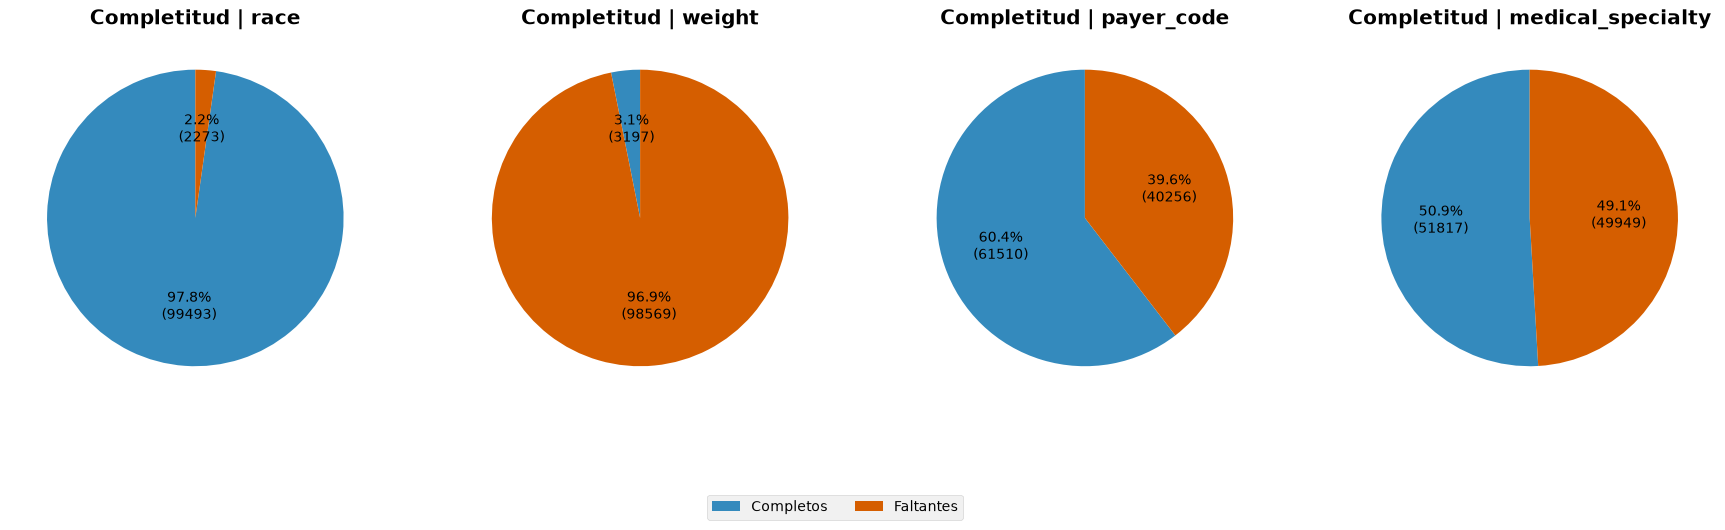

In [9]:
key = ['race', 'weight', 'payer_code', 'medical_specialty']
null_key = ['?', '?', '?', '?']
with plt.style.context('bmh'):
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))

    for i in range(4):
        faltantes = len(data_df[data_df[key[i]] == null_key[i]])
        completos = len(data_df[data_df[key[i]] != null_key[i]])
        total = completos + faltantes

        wedges, texts, autotexts = axes[i].pie(
            [completos, faltantes],
            autopct=lambda pct, total=total: f'{pct:.1f}%\n({int(round(pct/100*total))})',
            colors=['#348ABD', '#D55E00'],
            startangle=90
        )
        axes[i].set_title(f'Completitud | {key[i]}', fontweight='bold')

    fig.legend(
        wedges, ['Completos', 'Faltantes'],
        loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02)
    )

        
    plt.show()

Los atributos presentan niveles de calidad muy distintos. `race` tiene una tasa de incompletitud baja (2.2%), lo suficientemente pequeña para ser manejable en una fase de procesamiento posterior, donde los datos faltantes se pueden reemplazar utilizando alguna técnica de imputación clásica, o se podría considerar la eliminación de esos registros. Lo mismo no se puede decir del resto: `payer_code` carece de información en casi el 40% de los registros y `medical_specialty` en casi la mitad (49.1%), por lo que se requeriría utilizar técnicas de imputación más avanzadas, tratar la ausencia como una categoría propia, o eliminar los atributos; `weight` simplemente tiene una amplia mayoría de registros faltantes (96.9%).

Ahora, para los atributos de las pruebas de laboratorio, se grafica la proporción de encuentros en los que la prueba sí fue realizada:

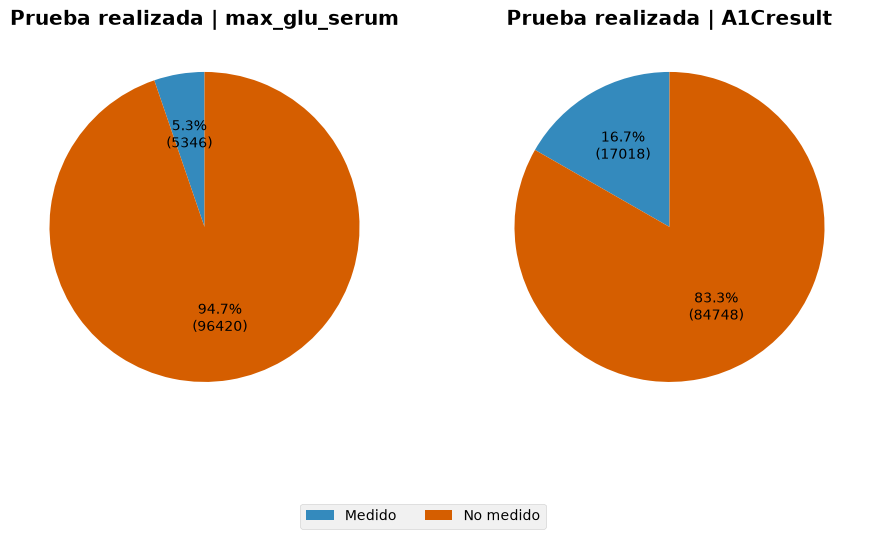

In [10]:
key = ['max_glu_serum', 'A1Cresult']
null_key  = 'None'
with plt.style.context('bmh'):
    fig, axes = plt.subplots(1, 2, figsize=(11, 6))

    for i in range(2):
        no_medidos = len(data_df[data_df[key[i]] == null_key])
        medidos = len(data_df[data_df[key[i]] != null_key])
        total = medidos + no_medidos

        wedges, texts, autotexts = axes[i].pie(
            [medidos, no_medidos],
            autopct=lambda pct, total=total: f'{pct:.1f}%\n({int(round(pct/100*total))})',
            colors=['#348ABD', '#D55E00'],
            startangle=90
        )
        axes[i].set_title(f'Prueba realizada | {key[i]}', fontweight='bold')

    fig.legend(
        wedges, ['Medido', 'No medido'],
        loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02)
    )

        
    plt.show()

Las pruebas de laboratorio de interés están lejos de ser la norma: la hemoglobina glucosilada (HbA1c) solo se midió en el 16.7% de los encuentros y la glucosa sérica en apenas el 5.3%. Como ya se mencionó, aquí `None` no es un dato faltante, sino la ausencia de la prueba.

---


## Análisis

Empezamos con las variables numéricas, primeramente por los atributos de utilización de servicios:

In [11]:
# Columnas numéricas de utilización de servicios
cols_numericas = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
                  'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
data_df[cols_numericas].describe().round(2).T # Describimos estadísticamente

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0


**Lectura:** El tiempo promedio de estancia es de 4.40 días (desv. est. de 2.99, mediana de 4), con una cola hacia estancias largas hasta el máximo de 14 días, que es el límite establecido por los criterios de inclusión del conjunto de datos. En promedio se realizan 43.10 pruebas de laboratorio por encuentro y se administran 16.02 medicamentos distintos; en este último, el máximo de 81 es un valor muy extraordinario comparado con el tercer cuartil de 20.

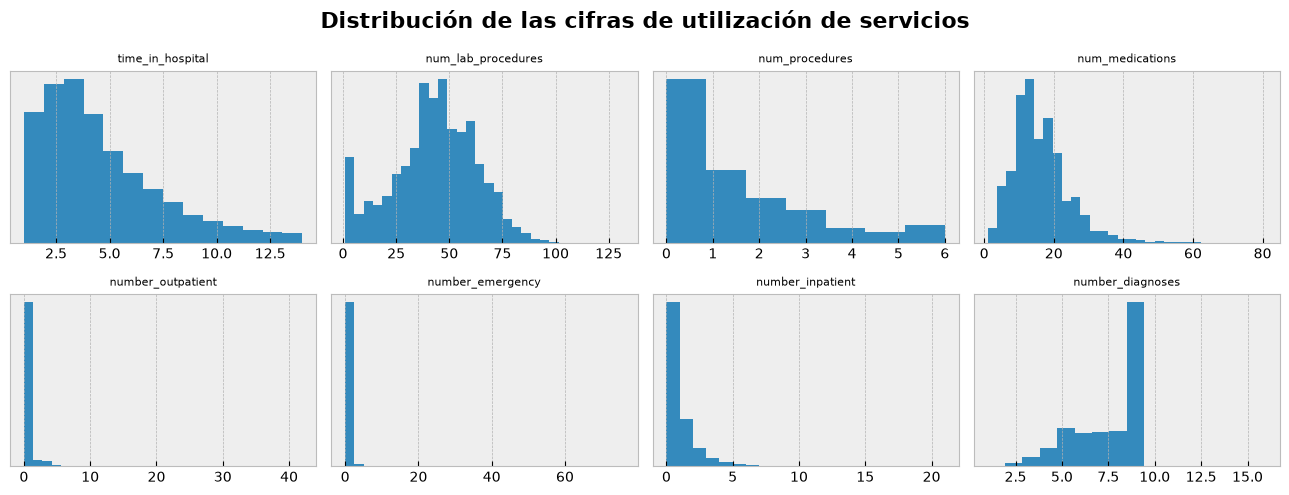

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

# Graficamos el histograma de distribución para cada atributo numérico
with plt.style.context('bmh'):
    for ax, col in zip(axes.ravel(), cols_numericas):
        ax.hist(data_df[col], bins=min(data_df[col].nunique(), 30))
        ax.set_title(col, fontsize=8)
        ax.set_yticks([])
    
    fig.suptitle("Distribución de las cifras de utilización de servicios",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

**Lectura**: `time_in_hospital`, `num_procedures` y `num_medications` presentan distribuciones asimétricas con cola hacia la derecha, mientras que `num_lab_procedures` es más simétrica y se concentra alrededor de 40-50 pruebas, con una pequeña concentración de encuentros con muy pocas pruebas. Las tres variables de visitas previas se concentran de manera extrema en cero. Llama la atención `number_diagnoses`, que muestra un pico muy marcado en el valor de 9 y casi nada por encima de ese valor, lo que sugiere que existe corte sobre ese nivel o similar.

Continuamos con los medicamentos para la diabetes: qué porcentaje de los encuentros incluyó la prescripción de cada uno de ellos, y cuántos medicamentos se prescribieron simultáneamente Para ello, se agrupan las columnas de medicamentos en un par de atributos nuevos: el número de medicamentos prescritos en el encuentro (`TOTAL_MEDS`) y el número de medicamentos cuya dosis fue ajustada, ya sea aumentada o disminuida (`TOTAL_MEDS_AJUSTADOS`). Además, se verifica si algún medicamento tiene una única categoría en todos los registros, pues no aportaría información alguna:

In [13]:
# Verificamos si hay medicamentos que nunca se registraron como prescritos (una sola categoría)
cols_constantes = [c for c in cols_meds if data_df[c].nunique() == 1]
print(f'Medicamentos con un único valor en todos los registros: {cols_constantes}')

# Creamos un par de columnas que agrupan el total de medicamentos prescritos y el de medicamentos con dosis ajustada
data_df['TOTAL_MEDS'] = (data_df[cols_meds] != 'No').sum(axis=1)
data_df['TOTAL_MEDS_AJUSTADOS'] = data_df[cols_meds].isin(['Up', 'Down']).sum(axis=1)

# Eliminamos los atributos sin variabilidad, que no aportan información
data_df = data_df.drop(columns=cols_constantes)
cols_meds = [c for c in cols_meds if c not in cols_constantes]

Medicamentos con un único valor en todos los registros: ['examide', 'citoglipton']


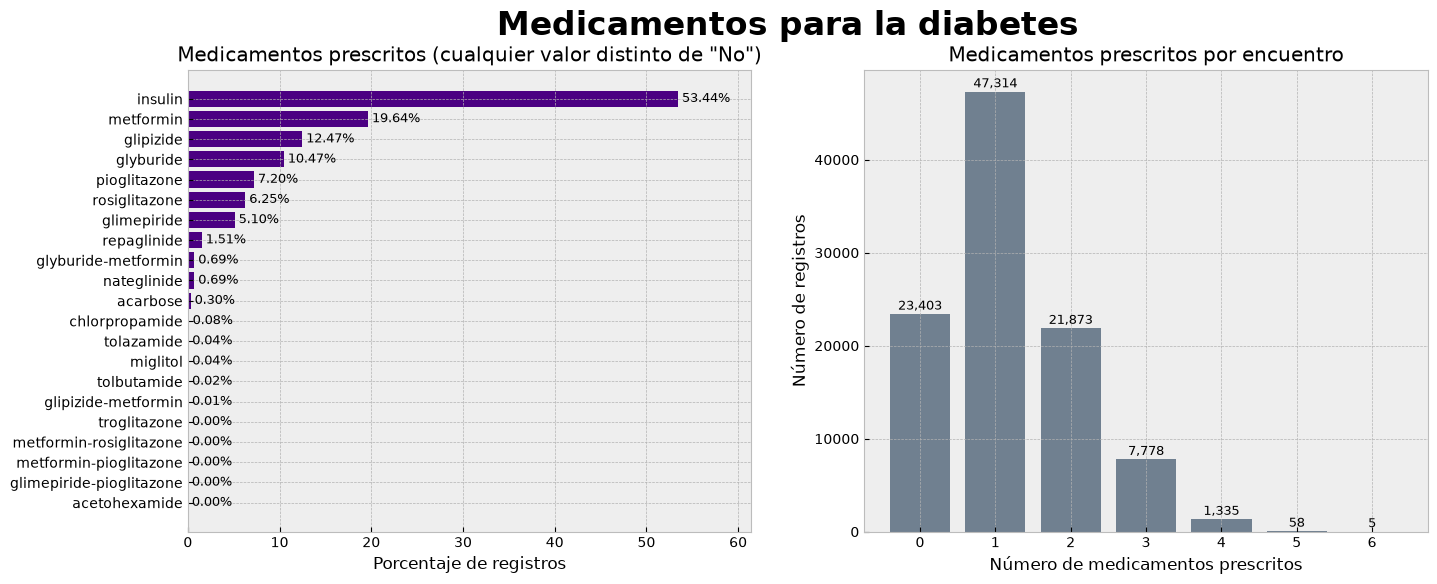

In [14]:
prev_meds = ((data_df[cols_meds] != 'No').mean() * 100).sort_values(ascending=True)

with plt.style.context('bmh'):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Medicamentos para la diabetes', fontweight='bold', fontsize=24)

    # Porcentaje de encuentros en los que cada medicamento fue prescrito
    ax[0].barh(prev_meds.index, prev_meds.values, color='indigo')
    ax[0].set_xlabel('Porcentaje de registros')
    ax[0].set_title('Medicamentos prescritos (cualquier valor distinto de "No")')
    for i, v in enumerate(prev_meds.values):
        ax[0].text(v, i, f' {v:.2f}%', va='center', fontsize=9)
    ax[0].set_xlim(0, prev_meds.max() * 1.15)

    # Número de medicamentos prescritos simultáneamente
    table = pd.DataFrame({'TOTAL_MEDS': data_df['TOTAL_MEDS'].value_counts().sort_index().index,
                          'total': data_df['TOTAL_MEDS'].value_counts().sort_index().values})
    ax[1].bar(table['TOTAL_MEDS'], table['total'], color='slategrey')
    ax[1].set_xlabel('Número de medicamentos prescritos')
    ax[1].set_ylabel('Número de registros')
    ax[1].set_title('Medicamentos prescritos por encuentro')
    for j, v in zip(table['TOTAL_MEDS'], table['total']):
        ax[1].text(j, v + max(table['total'])*0.01, f'{v:,}', ha='center', fontsize=9)
    
    plt.show()

**Lectura:** La insulina es, por mucho, el medicamento más prescrito (53.44% de los encuentros), seguida de la metformina (19.64%), la glipizida (12.47%) y la gliburida (10.47%). En total, solo siete medicamentos superan el 5% de los registros; el resto aparece en 1.51% o menos, y varios son prácticamente inexistentes (de 1 a 3 registros en todo el conjunto). Respecto al número de medicamentos prescritos por encuentro, cerca del 25% de los registros no recibió ninguno, la mayoría (la mitad, aproximadamente) recibió exactamente uno; los primeros 3 cuártiles representan de 0 a 2 medicaciones; la prescripción de 4 o más es rara.

In [15]:
data_df = data_df.drop(columns=['TOTAL_MEDS','TOTAL_MEDS_AJUSTADOS'])

Seguimos con los atributos categóricos, empezando por el perfil del paciente:

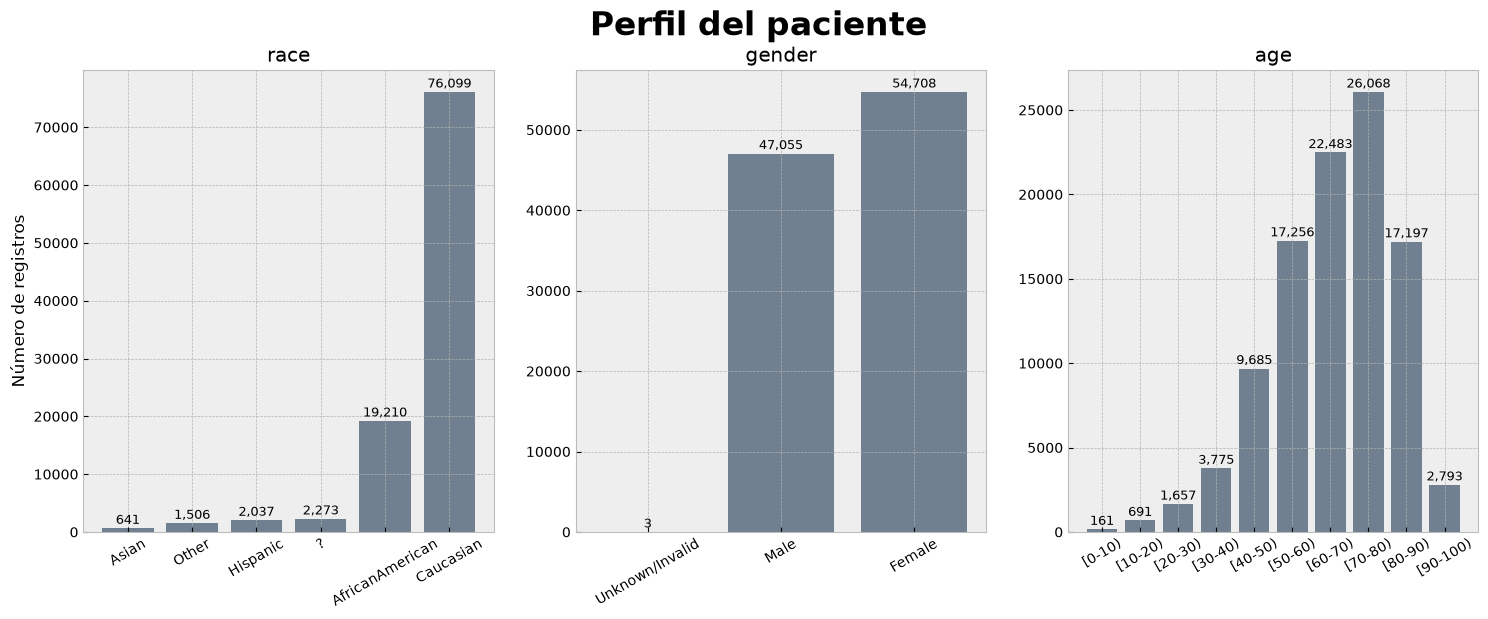

In [16]:
key = ['race', 'gender', 'age'] # Perfil del paciente

with plt.style.context('bmh'):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Perfil del paciente', fontweight='bold', fontsize=24)
    ax[0].set_ylabel('Número de registros')
    for i in range(3):
    
        table = pd.DataFrame({key[i]: data_df.loc[:, key[i]].value_counts().index,
                               'total': data_df.loc[:, key[i]].value_counts().values})
    
        if key[i] == 'age':
            table = table.sort_values('age') # Los grupos de edad tienen un orden natural
        else:
            table = table.sort_values('total', ascending=True)  
        
        ax[i].bar(table[key[i]], table['total'], color='slategrey')
        ax[i].set_title(key[i])
    
    
        for j, v in enumerate(table['total']):
            ax[i].text(j, v + max(table['total'])*0.01, f'{v:,}', ha='center', fontsize=9)
        ax[i].tick_params(axis='x', labelrotation=30)
        
    plt.show()

**Lectura:** Los datos están dominados por pacientes de raza `Caucasian` (~75%), seguidos de `AfricanAmerican`; el resto de las categorías no supera el más de 2,500 cada una. Hay un ligero predominio de mujeres sobre hombres, y solo 3 registros con género `Unknown/Invalid`. Por último, la distribución de la edad está fuertemente sesgada hacia los adultos mayores: el grupo más frecuente es el de 70 a 80 años (26,068 registros), la mayoría de los encuentros corresponde a pacientes de 60 años o más, y solo una minoría a menores de 40 años.

Los atributos de las pruebas de laboratorio y el tratamiento:

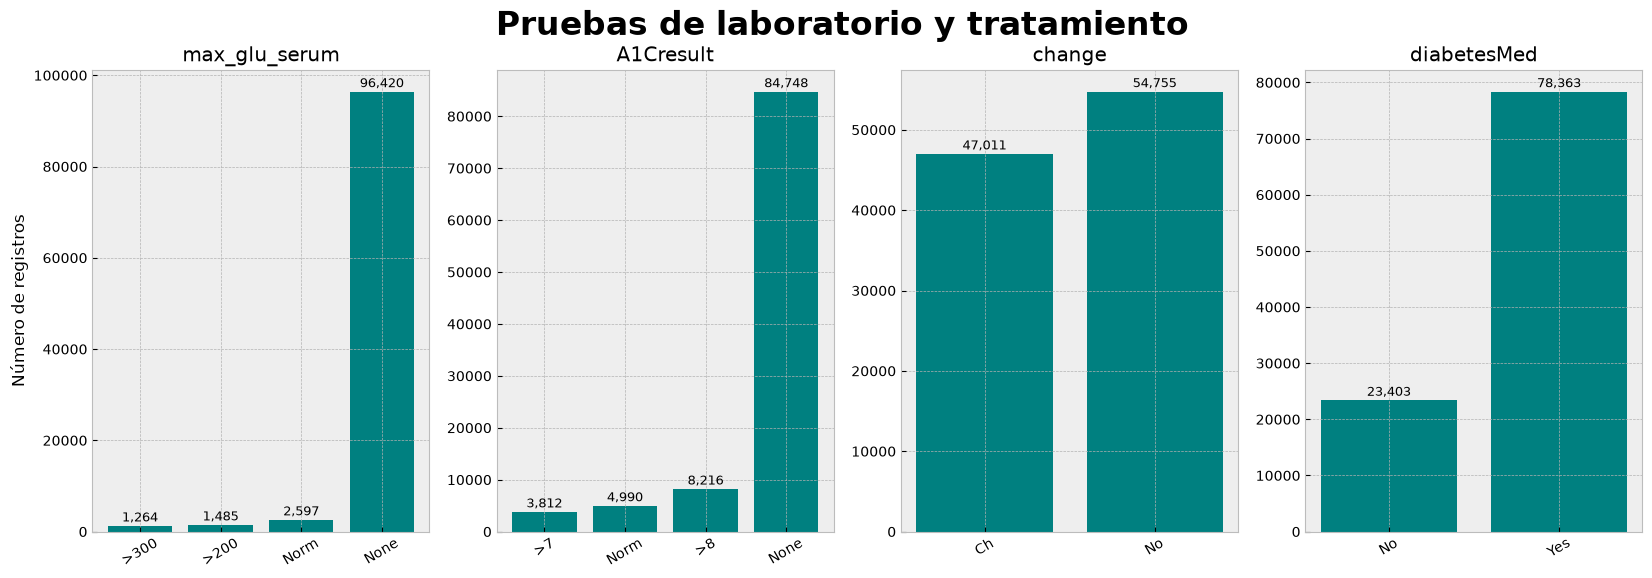

In [17]:
key = ['max_glu_serum', 'A1Cresult', 'change', 'diabetesMed'] # Pruebas de laboratorio y tratamiento

with plt.style.context('bmh'):
    fig, ax = plt.subplots(1, 4, figsize=(20, 6))
    fig.suptitle('Pruebas de laboratorio y tratamiento', fontweight='bold', fontsize=24)
    ax[0].set_ylabel('Número de registros')
    for i in range(4):
    
        table = pd.DataFrame({key[i]: data_df.loc[:, key[i]].value_counts().index,
                               'total': data_df.loc[:, key[i]].value_counts().values})
    
        table = table.sort_values('total', ascending=True)  
        
        ax[i].bar(table[key[i]], table['total'], color='teal')
        ax[i].set_title(key[i])
    
    
        for j, v in enumerate(table['total']):
            ax[i].text(j, v + max(table['total'])*0.01, f'{v:,}', ha='center', fontsize=9)
        ax[i].tick_params(axis='x', labelrotation=30)
        
    plt.show()

**Lectura:** Los histogramas confirman lo discutido en la sección de calidad respecto a las pruebas: arriba del 90% de los encuentros no se midió la glucosa sérica y en ~80% no se midió la HbA1c. Entre los encuentros en los que sí se realizó la HbA1c (17,018), el resultado más frecuente es >8 (~50%), es decir, casi la mitad de los pacientes evaluados presentaba un control glucémico deficiente. Por otro lado, en arriba del 40% de los encuentros hubo un cambio en la medicación (Ch), y en el ~80% se prescribió algún medicamento para la diabetes.

Ahora, la readmisión del paciente:

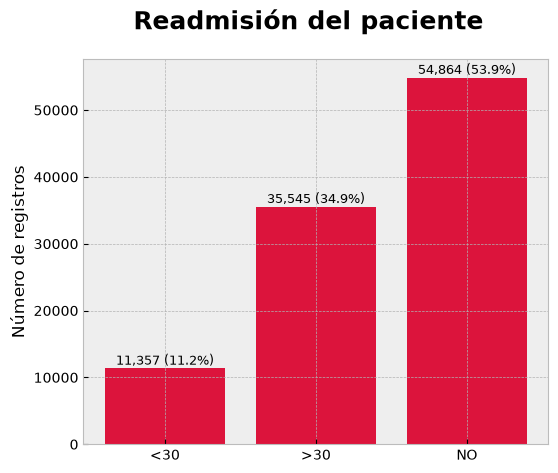

In [18]:
key = ['readmitted'] # Desenlace

with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(6, 5))
    fig.suptitle('Readmisión del paciente', fontweight='bold', fontsize=18)
    ax.set_ylabel('Número de registros')
    
    table = pd.DataFrame({key[0]: data_df.loc[:, key[0]].value_counts().index,
                           'total': data_df.loc[:, key[0]].value_counts().values})
    table = table.sort_values('total', ascending=True)
    
    ax.bar(table[key[0]], table['total'], color='crimson')
    
    for j, v in enumerate(table['total']):
        ax.text(j, v + max(table['total'])*0.01, f'{v:,} ({v/len(data_df)*100:.1f}%)', ha='center', fontsize=9)
        
    plt.show()

**Lectura:** La mayoría de los pacientes (arriba del 50%) no tiene registro de readmisión, el 34.9% fue readmitido después de 30 días, y solo el 11.2% (11,357 registros) fue readmitido en menos de 30 días. Es decir, la readmisión temprana, que es el desenlace de mayor interés del conjunto de datos, es una clase minoritaria (aproximadamente 1 de cada 9 encuentros), lo que implicaría un desbalance de clases en caso de modelarla.

Ahora, convertimos el atributo categórico de la readmisión a una escala numérica ordinal (1 = sin readmisión, 2 = readmisión después de 30 días y 3 = readmisión temprana, en menos de 30 días), conservando la columna original para poder etiquetar los gráficos. Cabe destacar que esta codificación supone que las tres categorías se ordenan en una escala de cercanía de la readmisión, lo cual es una simplificación:

In [19]:
data_df_readm = data_df.copy()

# Escala ordinal según la cercanía de la readmisión: sin readmisión < readmisión tardía < readmisión temprana
mapa_readmision = pd.DataFrame({'readmitted': ['NO', '>30', '<30'], 'clave': [1, 2, 3]})
mapping = mapa_readmision.set_index('readmitted')['clave']

data_df_readm['READM_ORD'] = data_df_readm['readmitted'].map(mapping)

**Pregunta: ¿cómo se relaciona el tiempo de estancia con la readmisión del paciente?**

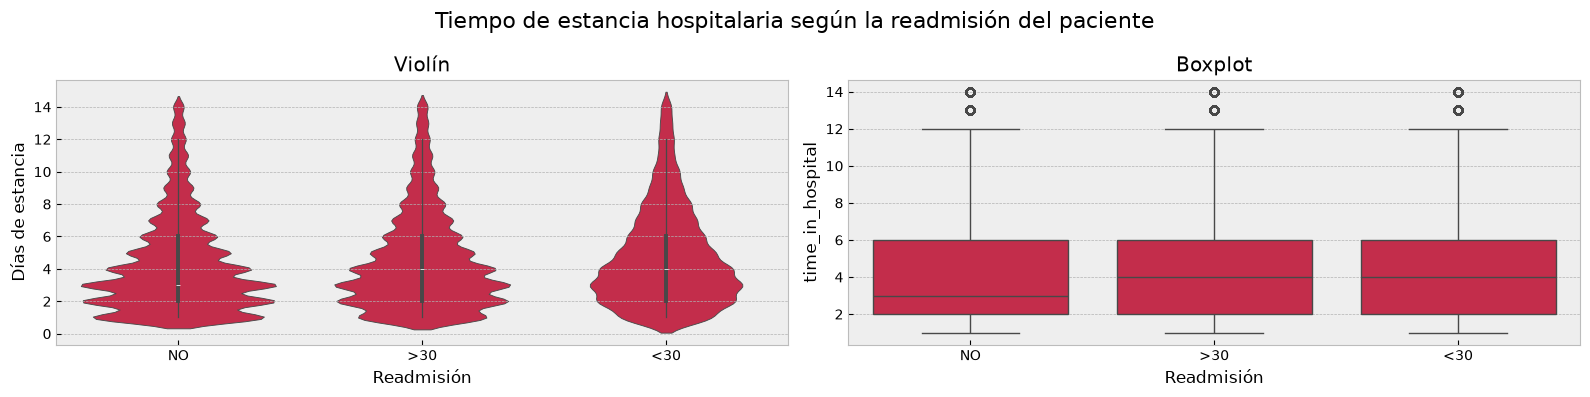

In [20]:
with plt.style.context('bmh'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle('Tiempo de estancia hospitalaria según la readmisión del paciente', size=16)
    table = data_df_readm
    orden = ['NO', '>30', '<30']

    sns.violinplot(data=table, x="readmitted", y="time_in_hospital",
                   order=orden, color='crimson', ax=axes[0])
    axes[0].set_xlabel("Readmisión")
    axes[0].set_ylabel("Días de estancia")
    axes[0].set_title("Violín")

    sns.boxplot(data=table, x="readmitted", y="time_in_hospital",
                order=orden, color='crimson', ax=axes[1])
    axes[1].set_xlabel("Readmisión")
    axes[1].set_title("Boxplot")

    plt.tight_layout()
    plt.show()

**Lectura:** El par de gráficos muestra la distribución de los días de estancia dependiendo de la readmisión. Las tres categorías presentan distribuciones muy similares, con la mayor parte de los registros concentrados entre 2 y 6 días (rango intercuartil idéntico en los tres boxplots) y datos atípicos de 13 y 14 días. Sin embargo, la mediana de estancia es de 3 días cuando no hay readmisión y de 4 días en los casos con readmisión; el violín de las readmisiones tempranas (`<30`) también es más ancho en las estancias largas.

**Pregunta: ¿cómo se relacionan las hospitalizaciones previas con la readmisión del paciente?**

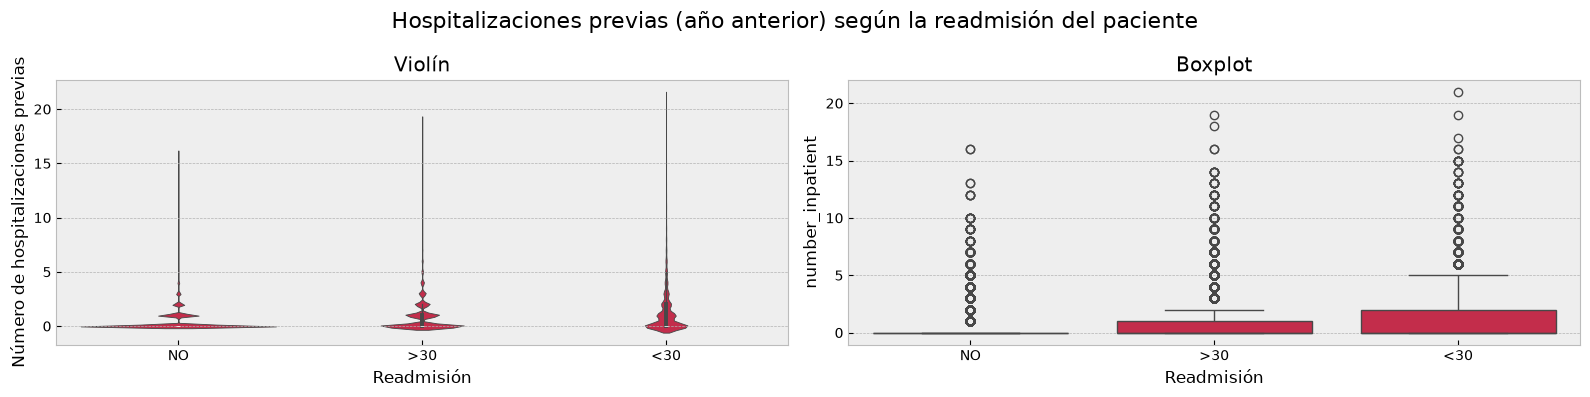

In [21]:
with plt.style.context('bmh'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle('Hospitalizaciones previas (año anterior) según la readmisión del paciente', size=16)
    table = data_df_readm
    orden = ['NO', '>30', '<30']

    sns.violinplot(data=table, x="readmitted", y="number_inpatient",
                   order=orden, color='crimson', ax=axes[0])
    axes[0].set_xlabel("Readmisión")
    axes[0].set_ylabel("Número de hospitalizaciones previas")
    axes[0].set_title("Violín")

    sns.boxplot(data=table, x="readmitted", y="number_inpatient",
                order=orden, color='crimson', ax=axes[1])
    axes[1].set_xlabel("Readmisión")
    axes[1].set_title("Boxplot")

    plt.tight_layout()
    plt.show()

**Lectura:** Aquí sí se observa una relación clara. Cuando no hay readmisión, la gran mayoría de los pacientes no tuvo hospitalizaciones previas (tercer cuartil de 0). En las readmisiones posteriores a 30 días, la caja del boxplot ya se extiende hasta 1 hospitalización, y en las readmisiones tempranas hasta 2. Asimismo, el máximo de hospitalizaciones previas crece con la cercanía de la readmisión. Es decir, los pacientes con hospitalizaciones recientes tienden a ser readmitidos con mayor frecuencia y de forma más temprana.

**Pregunta: ¿cómo cambian la cantidad de encuentros y la readmisión según el grupo de edad?**

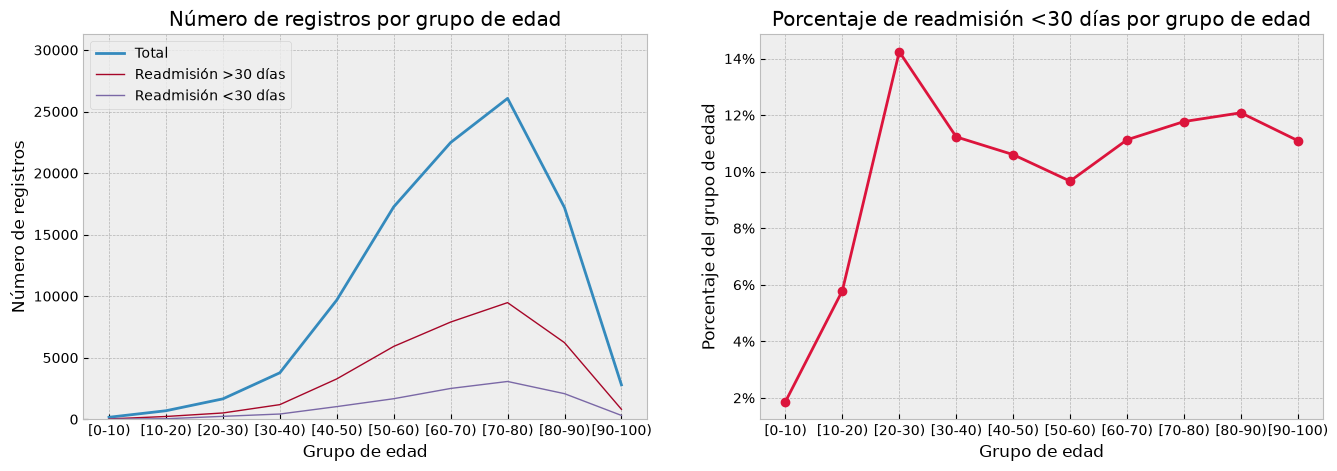

In [22]:
orden_edad = sorted(data_df['age'].unique(), key=lambda s: int(s.strip('[').split('-')[0]))

# Organizamos los grupos de edad (en orden) sobre los registros reportados
total_series = data_df.groupby('age').size().reindex(orden_edad)
tardia_series = data_df[data_df['readmitted'] == '>30'].groupby('age').size().reindex(orden_edad, fill_value=0)
temprana_series = data_df[data_df['readmitted'] == '<30'].groupby('age').size().reindex(orden_edad, fill_value=0)

with plt.style.context('bmh'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].plot(total_series.index, total_series.values, linewidth=2, label="Total")
    axes[0].plot(tardia_series.index, tardia_series.values, linewidth=1, label="Readmisión >30 días")
    axes[0].plot(temprana_series.index, temprana_series.values, linewidth=1, label="Readmisión <30 días")
    axes[0].set_title("Número de registros por grupo de edad")
    axes[0].set_xlabel("Grupo de edad")
    axes[0].set_ylabel("Número de registros")
    
    max_edad = total_series.idxmax()
    axes[0].set_ylim(0, total_series.max() * 1.2)
    axes[0].legend(frameon=True)
    
    # Porcentaje de readmisión temprana dentro de cada grupo de edad
    tasa_temprana = (temprana_series / total_series) * 100
    axes[1].plot(tasa_temprana.index, tasa_temprana.values, linewidth=2, color='crimson', marker='o')
    axes[1].set_title("Porcentaje de readmisión <30 días por grupo de edad")
    axes[1].set_xlabel("Grupo de edad")
    axes[1].set_ylabel("Porcentaje del grupo de edad")
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    
    plt.show()

**Lectura:** En la gráfica de la izquierda, el número de encuentros crece con la edad hasta alcanzar su máximo en el grupo de 70 a 80 años y cae drásticamente después; las curvas de las readmisiones siguen la misma forma, por lo que reflejan principalmente cómo se distribuyen las edades en el conjunto. Por ello, la gráfica de la derecha resulta más útil: el porcentaje de readmisión temprana es muy bajo en el grupo de 0 a 10 años, alrededor de 3 casos), sube hasta un máximo de ~15% en el grupo de 20 a 30 años, desciende hasta 10% en el grupo de 50 a 60 años y vuelve a subir hasta 12% en el grupo de 80 a 90 años. Cabe destacar que los grupos más jóvenes tienen muy pocos registros, por lo que sus porcentajes son inestables.

Calculamos la matriz de correlación entre la readmisión (en su escala ordinal) y los atributos numéricos de utilización de servicios, junto con el total de medicamentos prescritos:

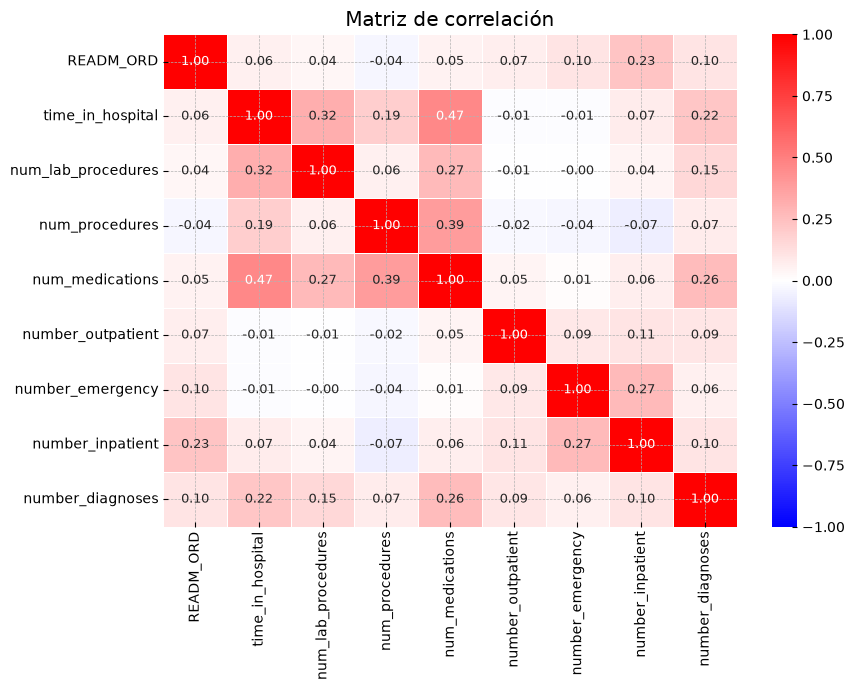

In [23]:
cols_corr = ['READM_ORD', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
             'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

correlaciones = data_df_readm[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(correlaciones, cmap="bwr", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.6, linecolor="white", ax=ax)

ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

**Lectura:** Las correlaciones más fuertes de la matriz se dan entre variables que describen la intensidad de la atención: `time_in_hospital` y `num_medications` (0.47), `num_procedures` y `num_medications` (0.39) y `time_in_hospital` y `num_lab_procedures` (0.32); el atributo `num_medications` destaca como el más conectado con el resto, lo cual es coherente con que una estancia más larga y más compleja implique más medicamentos y procedimientos. Con respecto a la readmisión (`READM_ORD`), la correlación más alta con diferencia es la de `number_inpatient` (0.23), seguida de `number_emergency` y `number_diagnoses` (0.10 cada una); el resto de atributos se correlaciona muy débilmente.

---

## Limpieza 

Primeramente, se verifica la completitud de los datos, retomando lo anteriormente visto durante la exploración:

In [24]:
for col in [['?', 'race'], ['?', 'weight'], ['?', 'payer_code'], ['?', 'medical_specialty'],
            ['?', 'diag_1'], ['?', 'diag_2'], ['?', 'diag_3'], ['Unknown/Invalid', 'gender']]:
    # Contamos los registros que reportan el código de dato faltante de acuerdo al diccionario
    n = (data_df[col[1]] == col[0]).sum()
    print(f"¿Se encontró un valor no reportado para '{col[1]}' (código '{col[0]}')?: {col[0] in data_df[col[1]].unique()} | {n} registros ({n/len(data_df)*100:.2f}%)")

¿Se encontró un valor no reportado para 'race' (código '?')?: True | 2273 registros (2.23%)
¿Se encontró un valor no reportado para 'weight' (código '?')?: True | 98569 registros (96.86%)
¿Se encontró un valor no reportado para 'payer_code' (código '?')?: True | 40256 registros (39.56%)
¿Se encontró un valor no reportado para 'medical_specialty' (código '?')?: True | 49949 registros (49.08%)
¿Se encontró un valor no reportado para 'diag_1' (código '?')?: True | 21 registros (0.02%)
¿Se encontró un valor no reportado para 'diag_2' (código '?')?: True | 358 registros (0.35%)
¿Se encontró un valor no reportado para 'diag_3' (código '?')?: True | 1423 registros (1.40%)
¿Se encontró un valor no reportado para 'gender' (código 'Unknown/Invalid')?: True | 3 registros (0.00%)


Como se puede apreciar, todos los atributos verificados reportan datos faltantes, aunque en proporciones muy distintas.

#### Atributos descartados

* `weight` (96.86% de datos faltantes): solo 3,197 de los 101,766 registros reportan este atributo. Se elimina.
* `payer_code` (39.56% de datos faltantes): es un atributo administrativo (quién paga el servicio) con una pérdida de información casi del 40%, y su relación con el desenlace no pareciera ser relevante, se elimina.
* `medical_specialty` (49.08% de datos faltantes): Existe una pérdida de información casi total para la mitad de los registros, por lo que conservarla implicaría inventar el valor para la mitad de la tabla. Además, existe una Alta cardinalidad entre los registros, con hasta 72 especialidades distintas.

In [25]:
# Atributos descartados por su alta proporción de datos faltantes
cols_descartar = ['weight', 'payer_code', 'medical_specialty']

for col in cols_descartar:
    n = (data_df[col] == '?').sum()
    print(f"'{col}': {n} registros faltantes ({n/len(data_df)*100:.2f}%) -> se elimina")

data_df = data_df.drop(columns=cols_descartar)
print(f"\nDimensiones de la tabla tras el descarte: {data_df.shape[0]} registros, {data_df.shape[1]} atributos")

'weight': 98569 registros faltantes (96.86%) -> se elimina
'payer_code': 40256 registros faltantes (39.56%) -> se elimina
'medical_specialty': 49949 registros faltantes (49.08%) -> se elimina

Dimensiones de la tabla tras el descarte: 101766 registros, 45 atributos


De acuerdo a lo visto anteriormente al ver la distrubución de datos alegóricos a medicaciones pre-escritas, se decidió eliminar aquellos atributos en los que solo un porcentaje muy pequeño de los registros (<5%) tenían un reporte, reduciendo enormemente las dimensiones del conjunto al remover datos no muy significativos (comparados con las medicaciones restantes como `insulin` y `metformin`):

In [26]:
cols_meds = [
    "repaglinide", "glyburide-metformin", "nateglinide", "acarbose", "chlorpropamide", 
    "tolazamide", "miglitol", "tolbutamide", "glipizide-metformin", "troglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone", "glimepiride-pioglitazone",
    "acetohexamide"
]

data_df = data_df.drop(columns=cols_meds)

#### Registros eliminados

Los atributos `diag_1`, `diag_2`, `diag_3` y `gender` presentan una proporción mínima de datos faltantes (0.02%, 0.35%, 1.40% y 0.00%, respectivamente); por ello, se decide eliminar estos registros en lugar de imputarlos. 

In [27]:
total_inicial = len(data_df)

for col, codigo in [['diag_1', '?'], ['diag_2', '?'], ['diag_3', '?'], ['gender', 'Unknown/Invalid']]:
    antes = len(data_df)
    data_df = data_df[data_df[col] != codigo]
    print(f"'{col}': {antes - len(data_df)} registros eliminados")

data_df = data_df.reset_index(drop=True)
print(f"\nTotal de registros eliminados: {total_inicial - len(data_df)} | Registros restantes: {len(data_df)}")

'diag_1': 21 registros eliminados
'diag_2': 357 registros eliminados
'diag_3': 1144 registros eliminados
'gender': 3 registros eliminados

Total de registros eliminados: 1525 | Registros restantes: 100241


#### Atributos imputados por moda

El atributo `race` tiene una proporción de faltantes mínima, por lo que eliminar el atributo desperdiciaría información casi completa, mientras que imputar los pocos valores faltantes tiene un efecto muy pequeño sobre la distribución. Para la técnica de imputación se elige la moda, ya que se tratan de elementos categóricos, y que cuyo estadístico más significativo se trata de este.

In [28]:
moda = data_df.loc[data_df['race'] != '?', 'race'].mode()[0] # La moda se calcula sin considerar el código de dato faltante
n = (data_df['race'] == '?').sum()
data_df['race'] = data_df['race'].replace('?', moda)
print(f"'{'race'}': {n} registros imputados con la moda '{moda}'")

'race': 2189 registros imputados con la moda 'Caucasian'


#### Transformación de Variables

Las columnas `change` (valores Ch / No) y `diabetesMed` (valores Yes / No) representan atributos binarios. Se realiza la conversión de estas cadenas de texto a un formato booleano (True/False).

In [29]:
data_df['change'] = data_df['change'].map({'Ch': True, 'No': False})
data_df['diabetesMed'] = data_df['diabetesMed'].map({'Yes': True, 'No': False})

#### Encoding

#### Reclasificación

Las variables `admission_type_id`, `discharge_disposition_id` y `admission_source_id` presentan una elevada cardinalidad original (hasta 30 categorías por variable), con múltiples códigos infrecuentes o equivalentes a datos faltantes.

* **`admission_type_id` 5 clases:** Emergency_Urgent (1,2), Elective (3), Trauma (7), Newborn (4), Unknown_Missing (5, 6, 8).
* **`discharge_disposition_id`  7 clases:** Home (1), Home_Health (6,8), Transfer_Facility (2-5, 9, 10, 15, 22-24, 27-30), Expired (11,19-21), Hospice (13, 14), Left_AMA (7), Unknown_Outpatient_Other (12, 16-18, 25, 26).
* **`admission_source_id` 6 clases:** Emergency_Room (7), Referral (1-3), Transfer (4-6, 10, 18, 19, 22, 25, 26), Birth_Newborn (11-14, 23, 24), Law_Enforcement (8), Unknown_Missing (9, 15, 17, 20, 21).

In [30]:
map_admission_type = {
    1: 'Emergency',
    2: 'Urgent',
    3: 'Elective',
    4: 'Newborn_Trauma', 7: 'Newborn_Trauma',
    5: 'Unknown_Missing', 6: 'Unknown_Missing', 8: 'Unknown_Missing'
}

# 2. Diccionario discharge_disposition_id
map_discharge_disposition = {
    1: 'Home_Routine',
    6: 'Home_Health', 8: 'Home_Health',
    3: 'Nursing_Rehab_Facility', 4: 'Nursing_Rehab_Facility', 5: 'Nursing_Rehab_Facility', 
    15: 'Nursing_Rehab_Facility', 22: 'Nursing_Rehab_Facility', 23: 'Nursing_Rehab_Facility', 24: 'Nursing_Rehab_Facility',
    2: 'Hospital_Transfer', 9: 'Hospital_Transfer', 10: 'Hospital_Transfer', 27: 'Hospital_Transfer', 28: 'Hospital_Transfer', 29: 'Hospital_Transfer',
    11: 'Expired', 19: 'Expired', 20: 'Expired', 21: 'Expired',
    13: 'Hospice', 14: 'Hospice',
    7: 'Outpatient_AMA', 12: 'Outpatient_AMA', 16: 'Outpatient_AMA', 17: 'Outpatient_AMA',
    18: 'Unknown_Missing', 25: 'Unknown_Missing', 26: 'Unknown_Missing', 30: 'Unknown_Missing'
}

# 3. Diccionario admission_source_id
map_admission_source = {
    7: 'Emergency_Room',
    1: 'Referral', 2: 'Referral', 3: 'Referral', 8: 'Referral',
    4: 'Transfer_Hospital', 10: 'Transfer_Hospital', 22: 'Transfer_Hospital', 25: 'Transfer_Hospital',
    5: 'Transfer_Facility', 6: 'Transfer_Facility', 18: 'Transfer_Facility', 19: 'Transfer_Facility', 26: 'Transfer_Facility',
    11: 'Birth_Newborn', 12: 'Birth_Newborn', 13: 'Birth_Newborn', 14: 'Birth_Newborn', 23: 'Birth_Newborn', 24: 'Birth_Newborn',
    9: 'Unknown_Missing', 15: 'Unknown_Missing', 17: 'Unknown_Missing', 20: 'Unknown_Missing', 21: 'Unknown_Missing'
}

data_df['admission_type_grouped'] = data_df['admission_type_id'].map(map_admission_type)
data_df['discharge_disposition_grouped'] = data_df['discharge_disposition_id'].map(map_discharge_disposition)
data_df['admission_source_grouped'] = data_df['admission_source_id'].map(map_admission_source)

idx = data_df.columns.get_loc('admission_type_id')
data_df.insert(idx, 'admission_type_grouped', data_df.pop('admission_type_grouped'))
data_df.drop(columns=['admission_type_id'], inplace=True)

idx = data_df.columns.get_loc('discharge_disposition_id')
data_df.insert(idx, 'discharge_disposition_grouped', data_df.pop('discharge_disposition_grouped'))
data_df.drop(columns=['discharge_disposition_id'], inplace=True)

idx = data_df.columns.get_loc('admission_source_id')
data_df.insert(idx, 'admission_source_grouped', data_df.pop('admission_source_grouped'))
data_df.drop(columns=['admission_source_id'], inplace=True)

#### Duplicados

También verificamos si existen duplicados dentro de los registros. A diferencia de otros conjuntos de datos, aquí sí se cuenta con un identificador del encuentro (`encounter_id`), por lo que se decidió que este fuese el atributo clave para comprobar duplicidad, además de verificar si hay registros completamente repetidos:

In [31]:
key_cols = ['encounter_id']
sum_duplicados = data_df.duplicated(subset=key_cols, keep=False).sum()

print(f'Total de duplicados tomando como clave encounter_id: {sum_duplicados}')
print(f'Total de registros completamente duplicados: {data_df.duplicated().sum()}')

Total de duplicados tomando como clave encounter_id: 0
Total de registros completamente duplicados: 0


Puesto que no se encontraron registros duplicados, no se requerirá hacer ninguna operación de eliminación.

#### Eliminación de índices

Previo a las etapas de aumento de datos, extracción y reducción de características, se eliminan los identificadoras `encounter_id` y `patient_nbr`. Se trata de claves/índices de la tabla asignadas como instrumentos administrativos y de identidad de consultas e individuos, respectivamente. No representan atributos biológicos, clínicos ni comportamentales del paciente, por lo que carecen de significancia como posibles predictores.

In [32]:
cols_ids = ['encounter_id', 'patient_nbr']
data_df = data_df.drop(columns=cols_ids)

#### Resumen

Finalmente, se verifica que ya no queden códigos de dato faltante en los atributos tratados y se observa la forma final de la tabla:

In [33]:
print(f"Dimensiones finales: {data_df.shape[0]} registros, {data_df.shape[1]} atributos")
print(f"Códigos de dato faltante restantes ('?' o 'Unknown/Invalid'): {data_df.isin(['?', 'Unknown/Invalid']).sum().sum()}")
print(f"Atributos: {list(data_df.columns)}")

Dimensiones finales: 100241 registros, 29 atributos
Códigos de dato faltante restantes ('?' o 'Unknown/Invalid'): 0
Atributos: ['race', 'gender', 'age', 'admission_type_grouped', 'discharge_disposition_grouped', 'admission_source_grouped', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted']


---

## Aumento de datos


Tras la limpieza, el atributo objetivo `readmitted` presenta un desbalance considerable: la clase mayoritaria (NO, sin readmisión) concentra el 53.7% de los registros, mientras que >30 (readmisión posterior a 30 días) representa el 35.1% y <30 (readmisión temprana) solo el 11.2%.

Primero, se importan las herramientas adicionales que se utilizarán en las siguientes secciones:

In [34]:
import warnings
import sklearn
from time import perf_counter
from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel, mutual_info_classif
from sklearn.metrics import f1_score, accuracy_score, recall_score, ConfusionMatrixDisplay

#### Codificación

Las técnicas de aumento, t-SNE y selección de características requieren una matriz numérica, por lo que primero se codifican los atributos:

* Binarios (`gender`, `change`, `diabetesMed`): se codifican como 0/1.
* Edad (`age`): es ordinal, por lo que cada intervalo se sustituye por su punto medio (por ejemplo, `[10-20)` pasa a ser 15), conservando el orden y el espacio entre ventana.
* Nominales (raza, tipo de ingreso, procedencia, destino al egreso, diagnósticos agrupados, resultados de laboratorio y los siete medicamentos): *one-hot*, pues no existe un orden entre sus categorías.

In [35]:
data_df = data_df.drop(columns=['diag_1', 'diag_2', 'diag_3'])

In [36]:
enc_df = data_df.copy()
    
enc_df['gender'] = (enc_df['gender'] == 'Male').astype(int)
enc_df['change'] = enc_df['change'].astype(int)
enc_df['diabetesMed'] = enc_df['diabetesMed'].astype(int)

# Edad: atributo ordinal, se sustituye cada intervalo por su punto medio
enc_df['age'] = enc_df['age'].str.extract(r'\[(\d+)-')[0].astype(int) + 5

# Variable objetivo
y = enc_df.pop('readmitted')

# Atributos nominales: one-hot
cols_nominales = ['race', 'admission_type_grouped', 'discharge_disposition_grouped', 'admission_source_grouped',
                  'max_glu_serum', 'A1Cresult',
                  'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
X = pd.get_dummies(enc_df, columns=cols_nominales, dtype=int)

cols_numericas = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
                  'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
cols_binarias = ['gender', 'change', 'diabetesMed']

# Posiciones de las columnas numéricas y categóricas (0/1), y bloques de columnas que pertenecen a una misma variable categórica
idx_num = [X.columns.get_loc(c) for c in cols_numericas]
idx_cat = [i for i in range(X.shape[1]) if i not in idx_num]
idx_edad = X.columns.get_loc('age')
bloques = [[X.columns.get_loc(c)] for c in cols_binarias]
for c in cols_nominales:
    bloques.append([i for i, k in enumerate(X.columns) if k.startswith(c + '_')])

print(f"Dimensiones: {X.shape[0]} registros, {X.shape[1]} atributos")
print(f"Numéricos: {len(cols_numericas)} | binarios: {len(cols_binarias)} | one-hot: {len(idx_cat) - len(cols_binarias)} columnas de {len(cols_nominales)} variables nominales")

Dimensiones: 100241 registros, 72 atributos
Numéricos: 9 | binarios: 3 | one-hot: 60 columnas de 13 variables nominales


#### Partición


Se divide el conjunto en entrenamiento (60%), validación (20%) y prueba (20%), estratificando por `readmitted`. El entrenamiento se utilizará para aumentar los datos y ajustar los modelos, la validación para comparar alternativas, y la prueba para una única evaluación final.

In [37]:
ran = 66

X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=ran)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=ran)

orden_clases = ['NO', '>30', '<30']
print(f"Entrenamiento: {len(X_train)} | Validación: {len(X_val)} | Prueba: {len(X_test)}")
pd.DataFrame({'Entrenamiento': y_train.value_counts(), 'Validación': y_val.value_counts(),
              'Prueba': y_test.value_counts()}).loc[orden_clases]

Entrenamiento: 60144 | Validación: 20048 | Prueba: 20049


,Entrenamiento,Validación,Prueba
readmitted,,,
NO,32291,10763,10764
>30,21103,7035,7035
<30,6750,2250,2250


#### Técnicas de aumento

Se evalúan dos técnicas:

* Jittering: con desviación `SIGMA = 0.2`, las variables categóricas se conservan idénticas a las del caso base.
* SMOTE-NC: con `k = 5` vecinos más cercanos; el SMOTE clásico no puede interpolar una variable categórica, por lo que en cada variable categórica se toma la categoría más frecuente entre los vecinos del caso base.

Las funciones necesarias son las siguientes.

In [38]:
# Estandarización de las variables numéricas (calculada SOLO con entrenamiento)
# Las columnas categóricas (0/1) no se modifican
mu = X_train[cols_numericas].mean().to_numpy()
sd = X_train[cols_numericas].std(ddof=0).to_numpy()
lo = X_train[cols_numericas].min().to_numpy()
hi = X_train[cols_numericas].max().to_numpy()

def a_z(X_in):
    Z = np.asarray(X_in, dtype=float).copy()
    Z[:, idx_num] = (Z[:, idx_num] - mu) / sd
    return Z

# Regresa a las unidades originales y devuelve valores válidos
def de_z(Z):
    X_out = Z.copy()
    X_out[:, idx_num] = np.clip(np.round(X_out[:, idx_num] * sd + mu), lo, hi)
    X_out[:, idx_edad] = np.clip(np.round((X_out[:, idx_edad] - 5) / 10) * 10 + 5, 5, 95)
    return X_out


# Elige al azar casos de la clase y les suma ruido gaussiano N(0, sigma) en las variables numéricas
def jittering(Z_min, n_samples, sigma, rng):
    base = rng.integers(len(Z_min), size=n_samples)
    Z = Z_min[base].copy()
    Z[:, idx_num] += rng.normal(0, sigma, size=(n_samples, len(idx_num)))
    return Z

# SMOTE para datos mixtos (SMOTE-NC): las variables numéricas se interpolan entre un caso y uno de sus k vecinos;
# en cada variable categórica se toma la categoría más frecuente entre los k vecinos del caso base
def manual_smote_nc(Z_min, n_samples, k=5, rng=None):
    k = min(k, len(Z_min) - 1)
    vecinos = NearestNeighbors(n_neighbors=k + 1).fit(Z_min).kneighbors(Z_min, return_distance=False)[:, 1:]
    i = rng.integers(len(Z_min), size=n_samples)
    j = vecinos[i, rng.integers(k, size=n_samples)]
    lam = rng.uniform(0, 1, size=(n_samples, 1))

    Z = Z_min[i].copy()
    Z[:, idx_num] = Z_min[i][:, idx_num] + lam * (Z_min[j][:, idx_num] - Z_min[i][:, idx_num])

    Z_vec = Z_min[vecinos[i]] # (n_samples, k, atributos): los vecinos de cada caso base
    for b in bloques:
        votos = Z_vec[:, :, b].sum(axis=1)
        if len(b) == 1: # Variable binaria: voto mayoritario
            Z[:, b[0]] = (votos[:, 0] + rng.uniform(-1e-3, 1e-3, size=n_samples)) > k / 2
        else: # Variable nominal (one-hot): categoría más votada
            votos = votos + rng.uniform(0, 1e-3, size=votos.shape) # Desempate aleatorio
            Z[:, b] = 0
            Z[np.arange(n_samples), np.array(b)[votos.argmax(axis=1)]] = 1
    return Z

#### Comparación de técnicas

Para evaluar cada técnica, se generan los casos sintéticos con ambas técnicas y se comparan con los casos reales de la clase mediante cuatro medidas:

* KS (numéricas): diferencia máxima entre la distribución acumulada real y la sintética, promediada sobre los 9 atributos numéricos (0 = distribuciones idénticas).
* Dif. categorías (pp): diferencia promedio, en puntos porcentuales, entre la proporción de cada categoría en los casos reales y en los sintéticos.
* Perfiles nuevos (%): porcentaje de casos sintéticos cuya combinación de categorías no existe entre los pacientes reales de esa clase (una combinación nueva no es necesariamente inválida, pero tampoco está respaldada por ningún paciente real).
* Copias exactas (%): porcentaje de casos sintéticos idénticos a un caso real.

In [39]:
Z_train = a_z(X_train)
y_arr = y_train.to_numpy()
n_mayor = int((y_arr == 'NO').sum()) # Tamaño de la clase mayoritaria
SIGMA = 0.20

def fidelidad(X_real, X_sint):
    # KS: diferencia máxima entre las distribuciones acumuladas real y sintética (promedio de las 9 variables numéricas; 0 = idénticas)
    ks = np.mean([ks_2samp(X_real[:, c], X_sint[:, c]).statistic for c in idx_num])
    # Diferencia promedio (en puntos porcentuales) entre la proporción de cada categoría real y sintética
    dif_cat = np.abs(X_real[:, idx_cat].mean(axis=0) - X_sint[:, idx_cat].mean(axis=0)).mean() * 100
    # Porcentaje de casos sintéticos con una combinación de categorías que no existe entre los casos reales de la clase
    perfiles = set(map(tuple, X_real[:, idx_cat]))
    nuevos = np.mean([tuple(f) not in perfiles for f in X_sint[:, idx_cat]]) * 100
    # Porcentaje de casos sintéticos idénticos a un caso real
    reales = set(map(tuple, X_real))
    copias = np.mean([tuple(f) in reales for f in X_sint]) * 100
    return {'KS (numéricas)': ks, 'Dif. categorías (pp)': dif_cat, 'Perfiles nuevos (%)': nuevos, 'Copias exactas (%)': copias}

filas = []
for clase in ['>30', '<30']:
    m = y_arr == clase
    n_gen = n_mayor - int(m.sum())
    for nombre, f in [('Jittering', lambda r: jittering(Z_train[m], n_gen, SIGMA, r)),
                      ('SMOTE-NC', lambda r: manual_smote_nc(Z_train[m], n_gen, k=5, rng=r))]:
        X_sint = de_z(f(np.random.default_rng(ran)))
        filas.append({'clase': clase, 'técnica': nombre, 'sintéticos': n_gen,
                      **fidelidad(X_train.to_numpy(float)[m], X_sint)})
pd.DataFrame(filas).set_index(['clase', 'técnica']).round(3)

sintéticos  KS (numéricas)  Dif. categorías (pp)  \
clase técnica                                                       
>30   Jittering       11188           0.015                 0.188   
      SMOTE-NC        11188           0.022                 1.707   
<30   Jittering       25541           0.014                 0.122   
      SMOTE-NC        25541           0.023                 2.217   

                 Perfiles nuevos (%)  Copias exactas (%)  
clase técnica                                             
>30   Jittering                0.000               1.305  
      SMOTE-NC                 5.533               7.025  
<30   Jittering                0.000               1.026  
      SMOTE-NC                10.070               4.757

**Lectura:** En ambas clases, el *jittering* reproduce mejor los datos reales. Su KS es menor (0.015 y 0.014, contra 0.024 y 0.025 de SMOTE-NC) y casi no altera las proporciones de las categorías, pues cada caso sintético hereda las categorías de un paciente real. En cambio, SMOTE-NC desplaza las proporciones categóricas entre 2.4 y 2.7 puntos porcentuales y genera combinaciones de categorías sin respaldo en pacientes reales.

Para evaluar el rendimiento, se entrena el mismo clasificador de regresión logística con cada estrategia y se evalúa el F1 macro y el *recall* de la clase `<30` en el conjunto de validación, que siempre contiene datos reales. Como referencia se incluyen el entrenamiento sin aumento, el aumento por simple duplicación de casos (ruido igual a cero), y el uso de `class_weight='balanced'`, que balancea las clases sin crear datos:

In [40]:
def crear_modelo(class_weight=None):
    # Mismo clasificador para todas las comparaciones: estandarización + regresión logística
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=3000, class_weight=class_weight, random_state=ran)
    )

Xv = X_val.to_numpy(float)
cache = {} # Evita regenerar los mismos casos sintéticos

def generar(clase, tecnica, semilla):
    clave = (clase, tecnica, semilla)
    if clave not in cache:
        m = y_arr == clase
        n_gen = n_mayor - int(m.sum())
        rng = np.random.default_rng(semilla)
        if tecnica == 'SMOTE-NC':
            Z = manual_smote_nc(Z_train[m], n_gen, k=5, rng=rng)
        else: # 'Jittering' con la desviación indicada (SIGMA) o 'Duplicación' (sigma = 0)
            Z = jittering(Z_train[m], n_gen, 0.0 if tecnica == 'Duplicación' else SIGMA, rng)
        cache[clave] = de_z(Z)
    return cache[clave]

def entrenar_con(estrategia, semilla):
    # estrategia: técnica para (>30, <30)
    partes, etiquetas = [X_train.to_numpy(float)], [y_arr]
    for clase, tecnica in zip(['>30', '<30'], estrategia):
        X_sint = generar(clase, tecnica, semilla)
        partes.append(X_sint)
        etiquetas.append(np.full(len(X_sint), clase))
    return np.vstack(partes), np.concatenate(etiquetas)

estrategias = {
    'Duplicación aleatoria (sin ruido)': ('Duplicación', 'Duplicación'),
    'Jittering (ambas clases)': ('Jittering', 'Jittering'),
    'SMOTE-NC (ambas clases)': ('SMOTE-NC', 'SMOTE-NC'),
    'Mixta: >30 jittering, <30 SMOTE-NC': ('Jittering', 'SMOTE-NC'),
}

filas = []
def registrar(nombre, semilla, modelo, X_fit, y_fit):
    pred = modelo.fit(X_fit, y_fit).predict(Xv)
    filas.append({'estrategia': nombre, 'semilla': semilla, 'F1': f1_score(y_val, pred, average='macro'),
                  'recall <30': recall_score(y_val, pred, labels=['<30'], average=None)[0]})

registrar('Sin aumento', 0, crear_modelo(), X_train.to_numpy(float), y_arr)
registrar("Sin aumento + class_weight='balanced'", 0, crear_modelo('balanced'), X_train.to_numpy(float), y_arr)
for nombre, estrategia in estrategias.items():
    for semilla in [1, 2, 3]:
        X_fit, y_fit = entrenar_con(estrategia, semilla)
        registrar(nombre, semilla, crear_modelo(), X_fit, y_fit)

resumen = pd.DataFrame(filas).groupby('estrategia', sort=False)[['F1', 'recall <30']].agg(['mean', 'std']).round(4)
resumen

F1         recall <30        
                                         mean     std       mean     std
estrategia                                                              
Sin aumento                            0.3664     NaN     0.0116     NaN
Sin aumento + class_weight='balanced'  0.4339     NaN     0.4067     NaN
Duplicación aleatoria (sin ruido)      0.4348  0.0010     0.4110  0.0044
Jittering (ambas clases)               0.4360  0.0009     0.4102  0.0034
SMOTE-NC (ambas clases)                0.4121  0.0013     0.4039  0.0011
Mixta: >30 jittering, <30 SMOTE-NC     0.4039  0.0002     0.4218  0.0012

La tabla muestra que, sin aumento, el modelo casi no detecta la readmisión temprana (*recall* de `<30` de 0.012 y F1 macro de 0.366); al balancear las clases, el *recall* sube a alrededor de 0.41 y el F1 macro a 0.43. Entre las técnicas de aumento, el *jittering* en ambas clases obtiene el mayor F1 macro (0.436), por encima de SMOTE-NC (0.412) y de la estrategia mixta (0.404).

Por ello se elige *jittering* para ambas clases minoritarias, puesto que ofrece el mejor F1 macro con un *recall* equivalente al de las demás técnicas, y además conserva mejor la distribución de los datos reales.

Se aplica la técnica elegida sobre el conjunto de entrenamiento:

In [41]:
rng = np.random.default_rng(ran)

X_syn, y_syn = [], []
for clase in ['>30', '<30']:
    m = y_arr == clase
    n_gen = n_mayor - int(m.sum())
    X_syn.append(de_z(jittering(Z_train[m], n_gen, SIGMA, rng)))
    y_syn += [clase] * n_gen
    print(f"Clase {clase}: {int(m.sum())} reales + {n_gen} sintéticos")

X_syn = pd.DataFrame(np.vstack(X_syn), columns=X.columns).astype(int)

X_train_aug = pd.concat([X_train.reset_index(drop=True), X_syn], ignore_index=True)
y_train_aug = pd.concat([y_train.reset_index(drop=True), pd.Series(y_syn, name='readmitted')], ignore_index=True)
es_sintetico = np.r_[np.zeros(len(X_train), dtype=bool), np.ones(len(X_syn), dtype=bool)] # Marca los casos generados

print("\nDistribución después del aumento:", y_train_aug.value_counts().loc[orden_clases].to_dict())

Clase >30: 21103 reales + 11188 sintéticos
Clase <30: 6750 reales + 25541 sintéticos

Distribución después del aumento: {'NO': 32291, '>30': 32291, '<30': 32291}


El conteo de casos por clase antes y después del aumento:

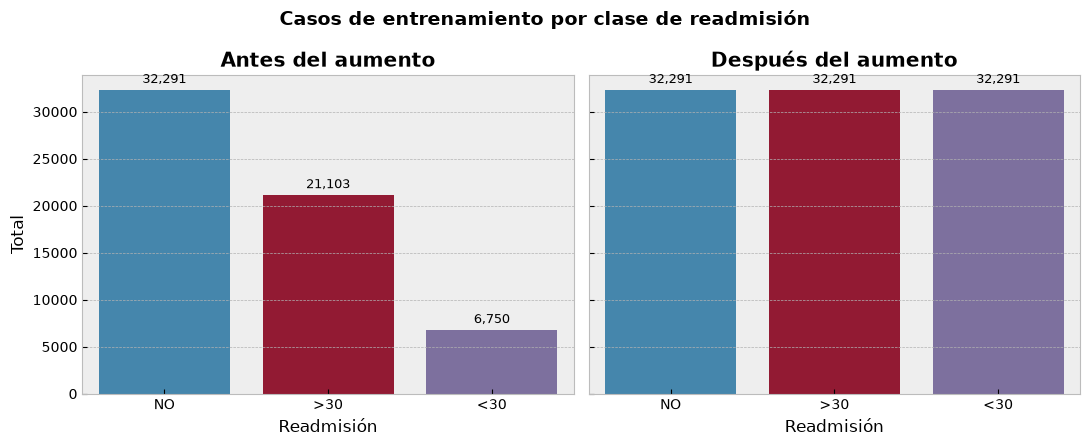

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

with plt.style.context('bmh'):
    for ax, y_plot, titulo in [(axes[0], y_train, 'Antes del aumento'), (axes[1], y_train_aug, 'Después del aumento')]:
        sns.countplot(x=y_plot, order=orden_clases, ax=ax, hue=y_plot, hue_order=orden_clases, legend=False)
        ax.set_title(titulo, fontweight='bold')
        ax.set_xlabel('Readmisión')
        ax.set_ylabel('Total')
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontsize=9)

    fig.suptitle('Casos de entrenamiento por clase de readmisión', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Se compara la distribución original con la sintética para cuatro atributos numéricos, en cada clase minoritaria (los histogramas se normalizan para poder comparar, pues hay distinto número de casos reales y sintéticos):

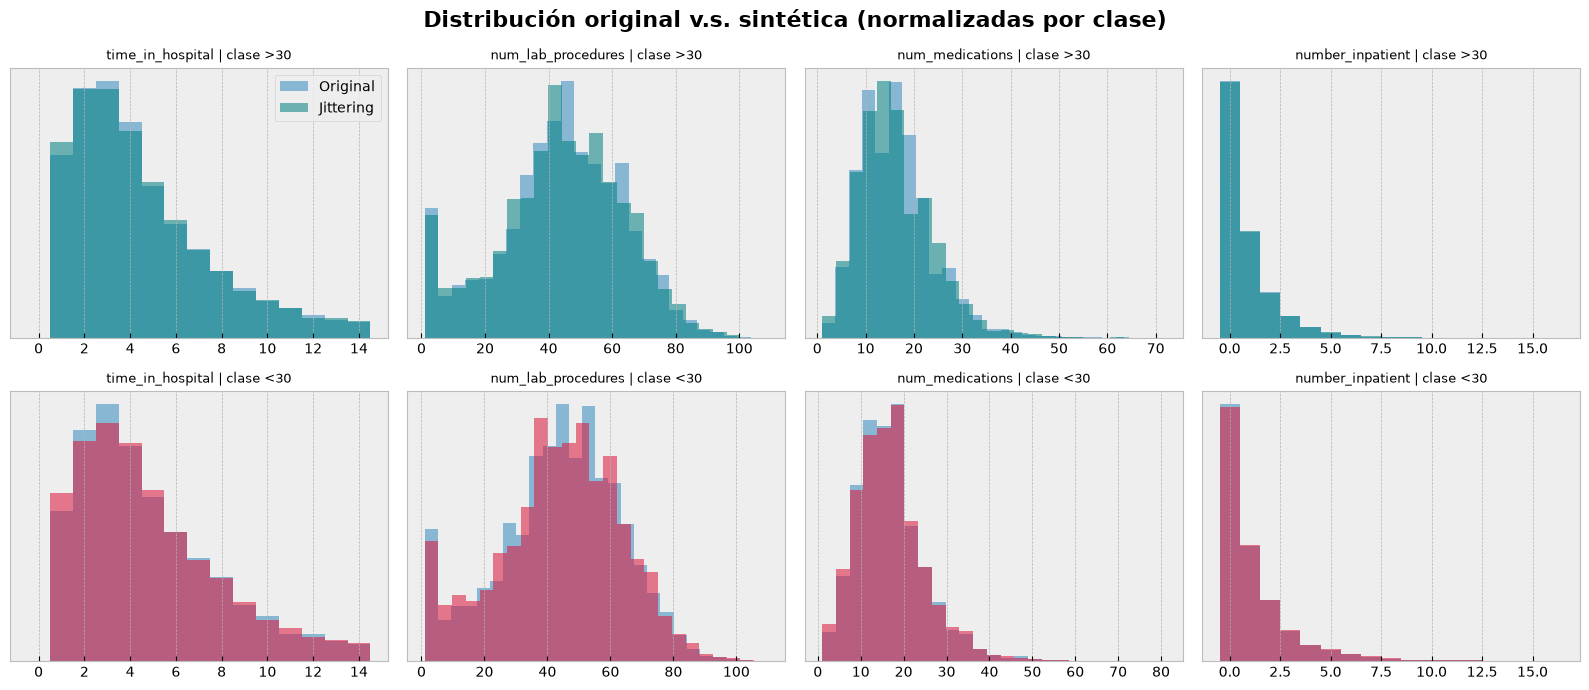

In [43]:
features = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_inpatient']
colores = {'>30': 'teal', '<30': 'crimson'}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

with plt.style.context('bmh'):
    for fila, clase in enumerate(['>30', '<30']):
        real = (y_train_aug.to_numpy() == clase) & ~es_sintetico
        sint = (y_train_aug.to_numpy() == clase) & es_sintetico
        for col, feature in enumerate(features):
            ax = axes[fila, col]
            vmax = X_train_aug[feature].max()
            bins = np.arange(-0.5, vmax + 1.5, 1) if vmax <= 30 else 25
            ax.hist(X_train_aug.loc[real, feature], bins=bins, alpha=.55, density=True, label='Original')
            ax.hist(X_train_aug.loc[sint, feature], bins=bins, alpha=.55, density=True, color=colores[clase], label='Jittering')
            ax.set_title(f'{feature} | clase {clase}', fontsize=9)
            ax.set_yticks([])
            if fila == 0 and col == 0:
                ax.legend()

    fig.suptitle('Distribución original v.s. sintética (normalizadas por clase)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

Las distribuciones sintéticas siguen de cerca a las originales en ambas clases, incluyendo la asimetría hacia la derecha de `time_in_hospital` y `num_medications`, y la forma bimodal de `num_lab_procedures` (con un grupo de encuentros con muy pocas pruebas). Las diferencias pequeñas entre barras se deben al redondeo de los valores a enteros. `number_inpatient` prácticamente no cambia, pues casi siempre vale cero o uno y un ruido de esta magnitud no altera el valor tras el redondeo.

---

## Extracción de características

Para la extracción se parte del conjunto de entrenamiento aumentado y se crean dos atributos nuevos, cada uno de los cuales resume un grupo de columnas dispersas (con muchos ceros). Se generan dos nuevos atributos:

* **`visitas_previas`:** suma de `number_outpatient`, `number_emergency` y `number_inpatient`, es decir, el total de visitas del paciente en el año previo. Cada uno de los tres conteos vale cero en la mayoría de los registros por lo que el total resume en una sola columna el uso previo de servicios de salud.
* **`n_meds_activos`:** número de medicamentos para la diabetes prescritos en el encuentro (de los siete que se conservaron, cuántos tienen un valor distinto de NO). Resume 28 columnas *one-hot* en un atributo que mide la intensidad del tratamiento.

Los atributos se calculan con una función, para poder aplicar exactamente la misma transformación a los conjuntos de validación y prueba:

In [44]:
meds = ['metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']

def extraer_caracteristicas(X_in):
    X_out = X_in.copy()
    X_out['visitas_previas'] = X_out['number_outpatient'] + X_out['number_emergency'] + X_out['number_inpatient']
    X_out['n_meds_activos'] = sum(1 - X_out[f'{m}_No'] for m in meds)
    return X_out

data_feat = extraer_caracteristicas(X_train_aug)
X_val_feat = extraer_caracteristicas(X_val)
X_test_feat = extraer_caracteristicas(X_test)

nuevas = ['visitas_previas', 'n_meds_activos']
data_feat[nuevas].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
visitas_previas,96873.0,1.48,2.58,0.0,0.0,1.0,2.0,80.0
n_meds_activos,96873.0,1.15,0.89,0.0,1.0,1.0,2.0,6.0


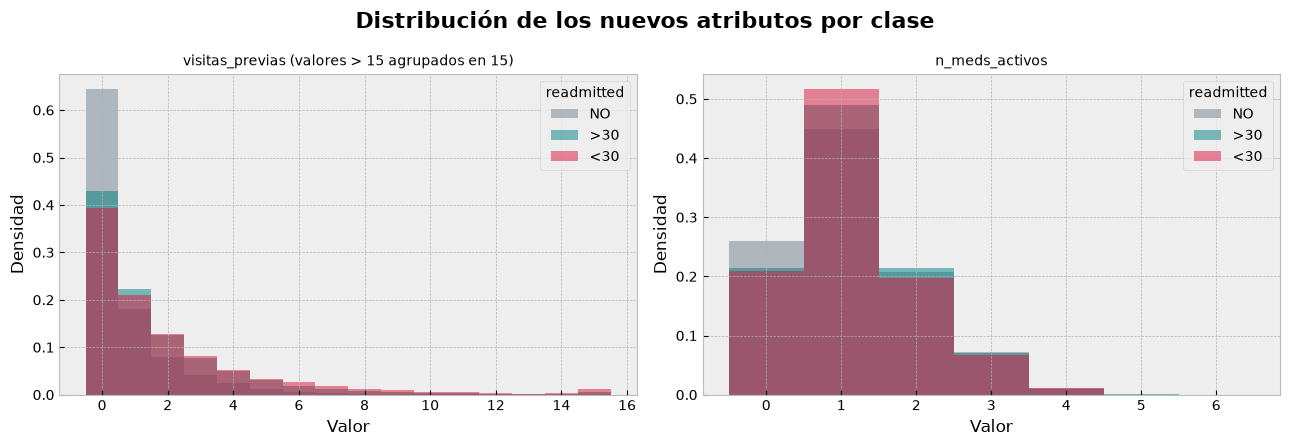

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colores_cl = {'NO': 'slategrey', '>30': 'teal', '<30': 'crimson'}

with plt.style.context('bmh'):
    for ax, col in zip(axes, nuevas):
        vmax = int(data_feat[col].max())
        bins = np.arange(-0.5, min(vmax, 15) + 1.5, 1)
        for clase in orden_clases:
            ax.hist(data_feat.loc[y_train_aug.to_numpy() == clase, col].clip(upper=15), bins=bins,
                    alpha=.5, density=True, color=colores_cl[clase], label=clase)
        ax.set_title(col + ' (valores > 15 agrupados en 15)' if col == 'visitas_previas' else col, fontsize=10)
        ax.set_xlabel('Valor'); ax.set_ylabel('Densidad')
        ax.legend(title='readmitted')

    fig.suptitle('Distribución de los nuevos atributos por clase', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

**Lectura:** Los dos atributos distinguen a la clase `NO` de las readmitidas, aunque no a `>30` de `<30`. El 64.5% de los casos `NO` no tuvo visitas previas, contra el 43.0% de `>30` y el 39.5% de `<30`; y el 26.0% de los `NO` no tuvo medicamentos prescritos, contra el 21.4% y el 20.9%. La diferencia es mucho más marcada en `visitas_previas` que en `n_meds_activos`.

---

## Reducción de dimensionalidad

Se aplica **t-SNE** para proyectar a dos dimensiones los atributos del conjuntoy observar si las clases de readmisión forman grupos. Se elige t-SNE por lo siguiente:

* Conserva las vecindades locales de los datos y puede representar relaciones no lineales. Al tener un número elevado de atributos, la complejidad aumenta y no sería apropiadamente explicada por una relación lineal.
* Esta la técnica ayudará a identificar si existen grupos o separabilidad entre clases.

t-SNE tiene limitaciones que determinan cómo se usa: no genera una transformación aplicable a datos nuevos, las distancias entre grupos lejanos no son interpretables y el resultado depende de la perplejidad. Por ello, se utiliza únicamente como herramienta de **visualización diagnóstica**, y no para generar atributos para los modelos. Además, dado que no escala bien a los ~97 mil casos del entrenamiento aumentado, se emplea una submuestra estratificada de 2,000 casos por clase. Las variables numéricas se estandarizan y las categóricas (0/1) se dejan sin modificar:

In [46]:
# Submuestra estratificada del entrenamiento aumentado (2,000 casos por clase), pues t-SNE no escala bien a ~97 mil casos
rng_ts = np.random.default_rng(ran)
idx_sub = np.concatenate([rng_ts.choice(np.where(y_train_aug.to_numpy() == c)[0], 2000, replace=False) for c in orden_clases])

X_sub = data_feat.iloc[idx_sub].reset_index(drop=True)
y_sub = y_train_aug.iloc[idx_sub].reset_index(drop=True)
sint_sub = es_sintetico[idx_sub]

# Estandarizamos las variables numéricas (y las dos extraídas); las categóricas (0/1) se dejan sin modificar
cols_std = cols_numericas + nuevas
escalador = StandardScaler().fit(data_feat[cols_std])
X_sub_z = X_sub.copy()
X_sub_z[cols_std] = escalador.transform(X_sub[cols_std])

pca = PCA(n_components=2).fit(X_sub_z)
print(f"Atributos: {X_sub_z.shape[1]} | casos en la submuestra: {len(X_sub_z)}")
print(f"Varianza explicada por las 2 primeras componentes de PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Casos sintéticos en la submuestra: {sint_sub.sum()} de {len(sint_sub)} | clase <30: {int((sint_sub & (y_sub == '<30').to_numpy()).sum())} de 2000")

Atributos: 74 | casos en la submuestra: 6000
Varianza explicada por las 2 primeras componentes de PCA: 29.4%
Casos sintéticos en la submuestra: 2311 de 6000 | clase <30: 1591 de 2000


Se aplica t-SNE con perplejidad de 30, inicialización por PCA y un máximo de 1,000 iteraciones, y se reporta la divergencia KL final como medida de qué tan bien la proyección conserva las vecindades:

In [47]:
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto',
            max_iter=1000, random_state=ran, n_jobs=1)
Z_tsne = tsne.fit_transform(X_sub_z)

print("Forma:", Z_tsne.shape)
print(f'KL final: {tsne.kl_divergence_:.4f}')

Forma: (6000, 2)
KL final: 2.2027


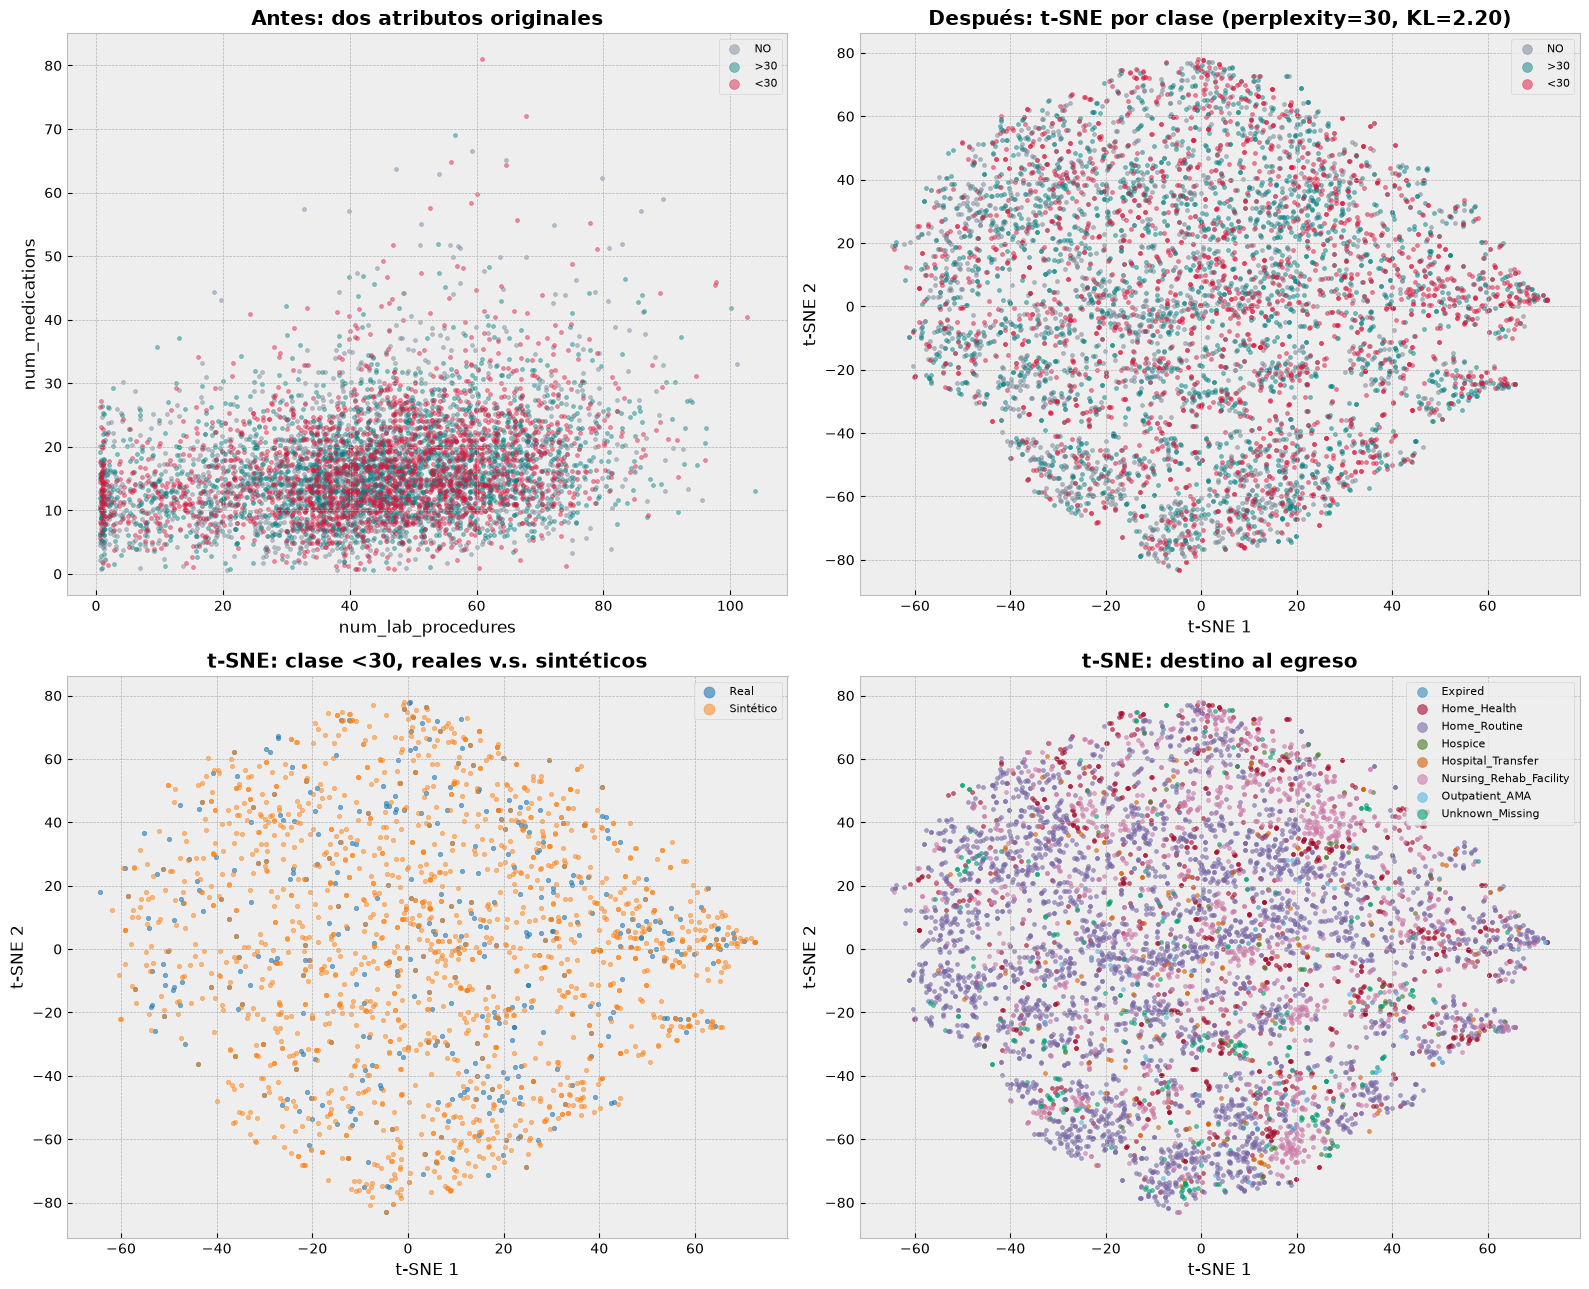

In [48]:
colores_cl = {'NO': 'slategrey', '>30': 'teal', '<30': 'crimson'}
destino = X_sub[[c for c in X_sub.columns if c.startswith('discharge_disposition_grouped_')]].idxmax(axis=1).str.replace('discharge_disposition_grouped_', '')
jit = np.random.default_rng(ran)

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

with plt.style.context('bmh'):
    # Antes: dos de los atributos originales (con una ligera dispersión visual para evitar que se encimen los enteros)
    for clase in orden_clases:
        m = (y_sub == clase).to_numpy()
        axes[0, 0].scatter(X_sub.loc[m, 'num_lab_procedures'] + jit.uniform(-.4, .4, m.sum()),
                           X_sub.loc[m, 'num_medications'] + jit.uniform(-.4, .4, m.sum()),
                           s=8, alpha=.45, color=colores_cl[clase], label=clase)
        axes[0, 1].scatter(Z_tsne[m, 0], Z_tsne[m, 1], s=8, alpha=.5, color=colores_cl[clase], label=clase)
    axes[0, 0].set_title('Antes: dos atributos originales', fontweight='bold')
    axes[0, 0].set_xlabel('num_lab_procedures'); axes[0, 0].set_ylabel('num_medications')
    axes[0, 1].set_title(f'Después: t-SNE por clase (perplexity=30, KL={tsne.kl_divergence_:.2f})', fontweight='bold')

    # Casos reales v.s. sintéticos de la clase <30 (la más aumentada)
    m30 = (y_sub == '<30').to_numpy()
    axes[1, 0].scatter(Z_tsne[m30 & ~sint_sub, 0], Z_tsne[m30 & ~sint_sub, 1], s=10, alpha=.6, color='#1f77b4', label='Real')
    axes[1, 0].scatter(Z_tsne[m30 & sint_sub, 0], Z_tsne[m30 & sint_sub, 1], s=10, alpha=.5, color='#ff7f0e', label='Sintético')
    axes[1, 0].set_title('t-SNE: clase <30, reales v.s. sintéticos', fontweight='bold')

    # Destino del paciente al egreso
    for categoria in sorted(destino.unique()):
        m = (destino == categoria).to_numpy()
        axes[1, 1].scatter(Z_tsne[m, 0], Z_tsne[m, 1], s=8, alpha=.6, label=categoria)
    axes[1, 1].set_title('t-SNE: destino al egreso', fontweight='bold')

    for ax in axes.ravel()[1:]:
        ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    for ax in axes.ravel():
        ax.legend(markerscale=2.5, fontsize=8)

    plt.tight_layout()
    plt.show()

**Lectura:**

* **Antes y después:** en los dos atributos originales, las tres clases se encuentran totalmente sobrepuestas; en la proyección de t-SNE siguen mezcladas, sin formar grupos separados por clase. Es decir, la reducción de dimensionalidad no revela una separabilidad que los atributos originales no mostraran, lo cual es coherente con las correlaciones débiles observadas en el análisis (la más alta con la readmisión fue de 0.23) y con el desempeño modesto de los clasificadores (F1 macro de alrededor de 0.43).
* **Casos sintéticos:** los casos sintéticos de la clase `<30` (1,591 de los 2,000 de la submuestra) se reparten por las mismas regiones que los reales, sin formar zonas aisladas ni artefactos, por lo que el *jittering* no introdujo estructura ajena a los datos.
* **Estructura existente:** la proyección sí presenta cierta estructura asociada al destino del paciente al egreso (por ejemplo, regiones con mayor concentración de pacientes enviados a rehabilitación o centros de enfermería), pero no a la clase de readmisión.

---

## Selección de características

Se eligió la regularización L1 por tres razones asociadas a este conjunto. Primeramente, las 72 columnas incluyen muchas variables dispersas, por lo que es importante captar esta redundancia; L1 evalúa las columnas de forma conjunta y lleva a cero las que no aportan. Por otro lado, es un método que utiliza el mismo tipo de modelo con el que se clasificará, por lo que las variables seleccionadas son las que ese modelo utilizará. Además,  su costo es mucho menos elevado que el que tendría un *wrapper* secuencial. Como limitación, la selección entre columnas correlacionadas podría descartar posibles descriptores conjuntos arbitrariamente.

Se estima el costo de un *wrapper* secuencial:

In [49]:
SEED = ran
subconjuntos = {'Sin selección': X_val_feat.columns.tolist()}
tiempos_seleccion = {'Sin selección': 0.0}

# El mismo clasificador se utilizará para evaluar todos los subconjuntos
modelo_base = crear_modelo().fit(data_feat, y_train_aug)
pred_base = modelo_base.predict(X_val_feat)
print(f"Atributos: {data_feat.shape[1]} | casos de entrenamiento (aumentado): {len(data_feat)}")
print(f"F1 macro de referencia en validación (todos los atributos): {f1_score(y_val, pred_base, average='macro'):.3f}")

Atributos: 74 | casos de entrenamiento (aumentado): 96873
F1 macro de referencia en validación (todos los atributos): 0.435


Un ajuste tarda alrededor de 1 segundo; un *forward* de apenas 20 variables requeriría 5,490 ajustes (aproximadamente 1 hora), y un *backward* hasta ese mismo tamaño, bastantes más. Se ajusta entonces la regresión logística con penalización L1:

In [55]:
escalador_integrados = StandardScaler().fit(data_feat)
Xt_std = escalador_integrados.transform(data_feat)

C_grid = [0.0003, 0.0005, 0.0008, 0.001, 0.002, 0.003]
coeficientes = {}

for C in C_grid:
    t0 = perf_counter()
    modelo = LogisticRegression(
        solver='saga', l1_ratio=1.0, C=C,
        max_iter=300, tol=1e-3, random_state=SEED
    ).fit(Xt_std, y_train_aug)
    coeficientes[C] = np.abs(modelo.coef_).sum(axis=0) 
    selector = SelectFromModel(modelo, prefit=True, threshold=1e-6)
    columnas = data_feat.columns[selector.get_support()].tolist()
    
    nombre = f'L1 (C={C})'
    subconjuntos[nombre] = columnas
    tiempos_seleccion[nombre] = perf_counter() - t0
    print(f"{nombre}: {len(columnas)} variables | iteraciones: {modelo.n_iter_.max()}")

L1 (C=0.0003): 6 variables | iteraciones: 14
L1 (C=0.0005): 9 variables | iteraciones: 9
L1 (C=0.0008): 15 variables | iteraciones: 13
L1 (C=0.001): 20 variables | iteraciones: 14
L1 (C=0.002): 37 variables | iteraciones: 25
L1 (C=0.003): 43 variables | iteraciones: 36


Cada subconjunto se evalúa entrenando el mismo clasificador sobre el entrenamiento aumentado y midiendo su desempeño en validación (datos reales):

In [56]:
resultados = []
for nombre, columnas in subconjuntos.items():
    modelo = crear_modelo().fit(data_feat[columnas], y_train_aug)
    prediccion = modelo.predict(X_val_feat[columnas])
    resultados.append({
        'método': nombre,
        'n_variables': len(columnas),
        'reducción_%': 100 * (1 - len(columnas) / data_feat.shape[1]),
        'F1_val': f1_score(y_val, prediccion, average='macro'),
        'accuracy_val': accuracy_score(y_val, prediccion),
        'selección_s': tiempos_seleccion[nombre]
    })
comparacion = pd.DataFrame(resultados).set_index('método')
comparacion.round(3)

,n_variables,reducción_%,F1_val,accuracy_val,selección_s
método,,,,,
Sin selección,74,0.000,0.435,0.498,0.000
L1 (C=0.0003),6,91.892,0.410,0.490,5.775
L1 (C=0.0005),9,87.838,0.425,0.489,3.935
L1 (C=0.0008),15,79.730,0.427,0.487,5.352
L1 (C=0.001),20,72.973,0.431,0.495,5.666
L1 (C=0.002),37,50.000,0.434,0.497,9.560
L1 (C=0.003),43,41.892,0.435,0.498,14.806


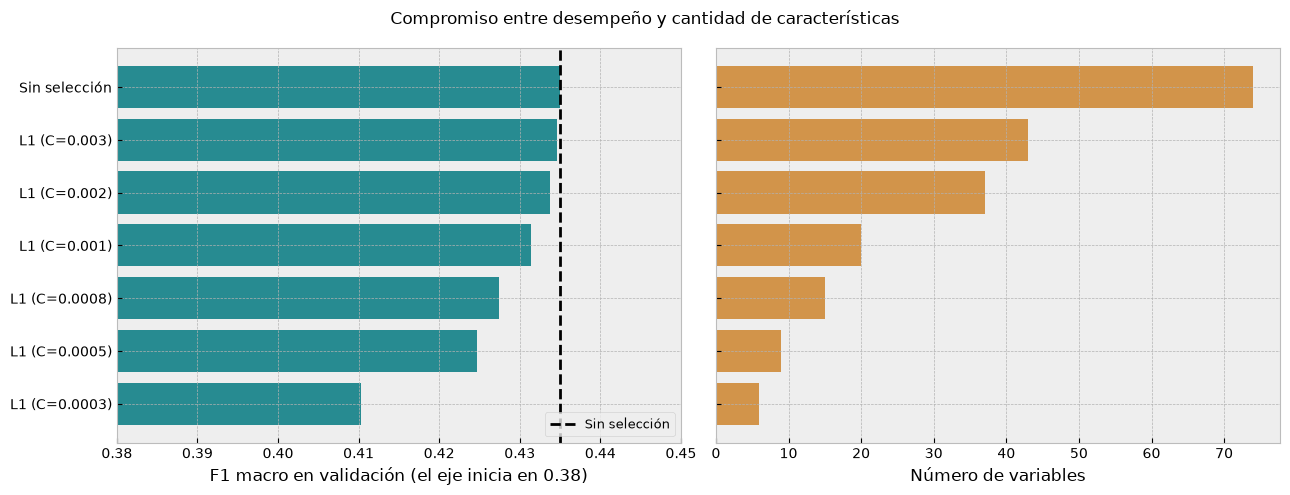

In [52]:
orden = comparacion.sort_values('n_variables').index
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
axes[0].barh(orden, comparacion.loc[orden, 'F1_val'], color='#278b91')
axes[0].axvline(comparacion.loc['Sin selección', 'F1_val'], color='black', linestyle='--', label='Sin selección')
axes[0].set_xlim(0.38, 0.45)
axes[0].set_xlabel('F1 macro en validación (el eje inicia en 0.38)')
axes[0].legend(loc='lower right', fontsize=9)
axes[1].barh(orden, comparacion.loc[orden, 'n_variables'], color='#d2944a')
axes[1].set_xlabel('Número de variables')
fig.suptitle('Compromiso entre desempeño y cantidad de características')
plt.tight_layout()
plt.show()

**Lectura:** Con muy pocas variables el desempeño cae (6 variables: F1 macro de 0.410; 9 variables: 0.425), pero a partir de 20 variables es prácticamente igual al del conjunto completo (0.432 contra 0.433 con las 72), e incluso con 25 variables es ligeramente mayor (0.435). Es decir, la gran mayoría de las columnas no aportan al clasificador.

#### Decisión y evaluación final

Entre los subconjuntos cuyo F1 en validación está lo más cercano al f1 del mejor, se elige el de menos variables. Se entrena el clasificador con el entrenamiento aumentado y las variables elegidas, y se evalúa una sola vez en el conjunto de prueba:

In [53]:
MARGEN_F1 = 0.005
candidatos = comparacion[
    comparacion['F1_val'] >= comparacion['F1_val'].max() - MARGEN_F1
].reset_index()
elegido = candidatos.sort_values(
    ['n_variables', 'F1_val', 'método'], ascending=[True, False, True]
).iloc[0]['método']
columnas_finales = subconjuntos[elegido]

# El clasificador se entrena con el conjunto de entrenamiento aumentado y se evalúa una sola vez en prueba (datos reales)
modelo_final = crear_modelo().fit(data_feat[columnas_finales], y_train_aug)
pred_test = modelo_final.predict(X_test_feat[columnas_finales])
pred_test_todas = modelo_base.predict(X_test_feat)

print('Subconjunto elegido con validación:', elegido, f'({len(columnas_finales)} variables)')
print('Variables:', columnas_finales)
print(f'F1 macro en prueba: {f1_score(y_test, pred_test, average="macro"):.3f} (con las {data_feat.shape[1]} variables: {f1_score(y_test, pred_test_todas, average="macro"):.3f})')
print(f'Accuracy en prueba: {accuracy_score(y_test, pred_test):.3f} (con las {data_feat.shape[1]} variables: {accuracy_score(y_test, pred_test_todas):.3f})')
print(f'Recall de <30 en prueba: {recall_score(y_test, pred_test, labels=["<30"], average=None)[0]:.3f} (con las {data_feat.shape[1]} variables: {recall_score(y_test, pred_test_todas, labels=["<30"], average=None)[0]:.3f})')

Subconjunto elegido con validación: L1 (C=0.001) (20 variables)
Variables: ['age', 'time_in_hospital', 'num_procedures', 'number_outpatient', 'number_inpatient', 'number_diagnoses', 'diabetesMed', 'admission_type_grouped_Unknown_Missing', 'discharge_disposition_grouped_Expired', 'discharge_disposition_grouped_Home_Health', 'discharge_disposition_grouped_Home_Routine', 'discharge_disposition_grouped_Hospice', 'discharge_disposition_grouped_Hospital_Transfer', 'discharge_disposition_grouped_Nursing_Rehab_Facility', 'admission_source_grouped_Emergency_Room', 'admission_source_grouped_Transfer_Facility', 'admission_source_grouped_Transfer_Hospital', 'metformin_No', 'insulin_Down', 'visitas_previas']
F1 macro en prueba: 0.433 (con las 74 variables: 0.433)
Accuracy en prueba: 0.495 (con las 74 variables: 0.495)
Recall de <30 en prueba: 0.411 (con las 74 variables: 0.415)


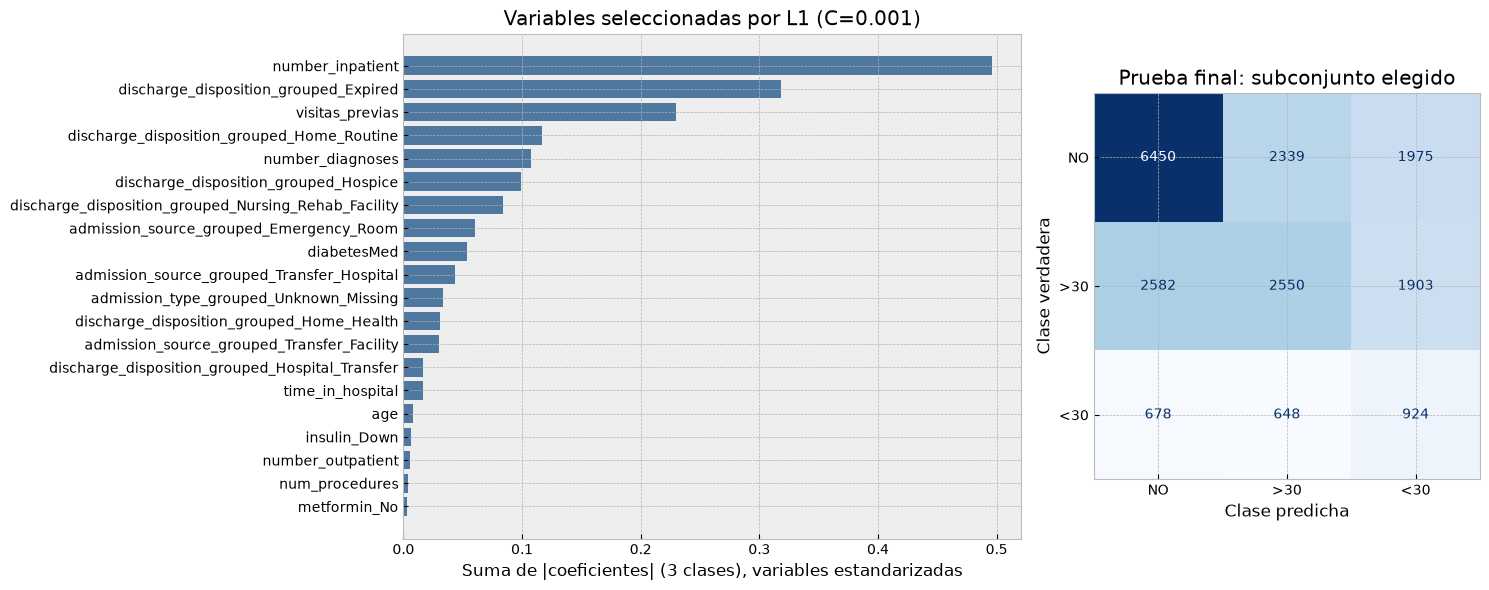

In [54]:
C_elegido = float(elegido.split('=')[1].rstrip(')'))
importancias = pd.Series(coeficientes[C_elegido], index=data_feat.columns)
importancias = importancias[columnas_finales].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1.6, 1]})
axes[0].barh(importancias.index, importancias.values, color='#4e78a0')
axes[0].set_xlabel('Suma de |coeficientes| (3 clases), variables estandarizadas')
axes[0].set_title(f'Variables seleccionadas por L1 (C={C_elegido})')

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, labels=orden_clases, cmap='Blues', colorbar=False, ax=axes[1]
)
axes[1].set_title('Prueba final: subconjunto elegido')
axes[1].set_xlabel('Clase predicha')
axes[1].set_ylabel('Clase verdadera')
plt.tight_layout()
plt.show()

**Lectura:** Se eligió C = 0.0008, que conserva 20 de las 72 variables. Increíblemente, el desempeño en prueba se mantiene, siendo el mismo F1 macro que el del conjunto de atributos completos; el *recall* de <30 disminuye un poco. Las variables con mayor peso son `number_inpatient`, la clase `Expired` de la disposición de egreso y `visitas_previas`, el atributo que fue extraído previamente. Sin embargo, el resto de atributos quedó muy lejos respecto a sus coeficientes en la jerarquía.

Sin embargo, hay que notar que la prueba tiene un sesgo aún muy marcado hacia los valores de clase que confirman que no hubo un reingreso. Esto se debe a que evidentemente, la sintetización de registros no emula del todo los datos reales y que fueron usados exclusívamente en la prueba. En lugar de usar una proporción tan elevada de datos artificiales, lo mejor sería balancear las clases mediante un corte a la clase mayoritaria (*undersampling*).

---

### Declaración de uso de Inteligencia Artificial Generativa
Para esta práctica se utilizó Claude para enlistar los atributos de la tabla durante la exploración del *dataset*. De igual manera se utilizó para programar las funciones de preprocesamiento de los datos categóricos con el fin de usarlos adecuádamente dentro de SMOTE-NC. Asímismo, se tomó como referencia código generado por medio de *prompts* para la validación necesaria al momento de comparar las dos técnicas de aumento de datos; también, para generar los diagramas de dispersión que permitieran visualizar los resultados de T-SNE y compararlos con la distribución del conjunto original. Por úlitmo, Claude también se empleó para revisar y corregir ortografía y estilo, particularmente en la exploración del dataset.

## Referencias
- Strack, B., DeShazo, J. P., Gennings, C., Olmo, J. L., Ventura, S., Cios, K. J., & Clore, J. N. (2014). Impact of HbA1c measurement on hospital readmission rates: Analysis of 70,000 clinical database patient records. *BioMed Research International, 2014*, Article 781670. https://doi.org/10.1155/2014/781670
- Strack, B., et al. (2014). *Diabetes 130-US Hospitals for Years 1999-2008* [Conjunto de datos]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/296/diabetes-130-us-hospitals-for-years-1999-2008